# Feature Engineering — Machine Learning Driven Supply Chain Cost Optimization   

### Table of Contents
1. Load Libraries & Data  
2. Table Joins & Master DataFrames  
3. Inventory Features  
4. Procurement Features  
5. Production Features  
6. Sales & Profitability Features  
7. Shipment & Logistics Features  
8. Supplier-Level Aggregated Features  
9. Customer-Level Aggregated Features  
10. Product-Level Aggregated Features  
11. Facility-Level Aggregated Features  
12. Time-Based Features  
13. Cross-Domain / Composite Features  
14. Encoding & Final Feature Matrix  
15. Feature Correlation & Selection  
16. Export Feature Sets  

---
## 1. Load Libraries & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# ── Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Global dark theme ────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0D1117',
    'axes.facecolor'    : '#161B22',
    'axes.edgecolor'    : '#30363D',
    'axes.labelcolor'   : '#C9D1D9',
    'xtick.color'       : '#8B949E',
    'ytick.color'       : '#8B949E',
    'text.color'        : '#C9D1D9',
    'grid.color'        : '#21262D',
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.6,
    'axes.grid'         : True,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 14,
    'axes.labelsize'    : 11,
    'legend.facecolor'  : '#161B22',
    'legend.edgecolor'  : '#30363D',
    'legend.fontsize'   : 9,
})

# ── Reusable color palettes ──────────────────
DARK_PALETTE  = ['#58A6FF','#3FB950','#F78166','#D2A8FF','#FFA657',
                 '#79C0FF','#56D364','#FF7B72','#BC8CFF','#FFB347']
GRADIENT_BLUE = sns.color_palette('Blues_r', 10)
GRADIENT_RED  = sns.color_palette('Reds_r',  10)
CMAP_DARK     = LinearSegmentedColormap.from_list('dark_heat',
                    ['#0D1117','#1F3A5F','#2E6DA4','#58A6FF','#A5D8FF'])

print('Libraries loaded. Dark theme applied.')

Libraries loaded. Dark theme applied.


In [2]:
# ── Load all tables  ──────────────────────────
dim_customer     = pd.read_csv('data/dim_customer.csv')
dim_date         = pd.read_csv('data/dim_date.csv')
dim_facility     = pd.read_csv('data/dim_facility.csv')
dim_product      = pd.read_csv('data/dim_product.csv')
dim_supplier     = pd.read_csv('data/dim_supplier.csv')
fact_inventory   = pd.read_csv('data/fact_inventory.csv')
fact_procurement = pd.read_csv('data/fact_procurement.csv')
fact_production  = pd.read_csv('data/fact_production.csv')
fact_sales       = pd.read_csv('data/fact_sales.csv')
fact_shipment    = pd.read_csv('data/fact_shipment.csv')

tables = {
    'dim_customer'    : dim_customer,
    'dim_date'        : dim_date,
    'dim_facility'    : dim_facility,
    'dim_product'     : dim_product,
    'dim_supplier'    : dim_supplier,
    'fact_inventory'  : fact_inventory,
    'fact_procurement': fact_procurement,
    'fact_production' : fact_production,
    'fact_sales'      : fact_sales,
    'fact_shipment'   : fact_shipment,
}

for name, df in tables.items():
    print(f'{name:25s} -> {df.shape[0]:>7,} rows  x  {df.shape[1]:>2} cols')

dim_customer              ->       5 rows  x   7 cols
dim_date                  ->   2,192 rows  x  11 cols
dim_facility              ->       5 rows  x   8 cols
dim_product               ->      20 rows  x  10 cols
dim_supplier              ->      10 rows  x   8 cols
fact_inventory            ->   8,000 rows  x   7 cols
fact_procurement          ->   3,000 rows  x  11 cols
fact_production           ->   9,000 rows  x   8 cols
fact_sales                -> 150,000 rows  x  14 cols
fact_shipment             ->  12,000 rows  x  13 cols


---
## 2. Table Joins & Master DataFrames
We build enriched, denormalized DataFrames by joining each fact table with its relevant dimension tables. This gives us context (product names, supplier tiers, dates, etc.) alongside every transaction.

In [3]:
# ── 2.1 Procurement master  ───────────────────
proc = fact_procurement.copy()

proc = proc.merge(

    dim_product[['product_id','product_name','category','product_line',
                 'unit_price','unit_cost','weight_kg']],
    on='product_id', how='left'
)
proc = proc.merge(
    dim_supplier[['supplier_id','supplier_name','country','specialty',
                  'tier','avg_quality_score']],
    on='supplier_id', how='left'
)
proc = proc.merge(
    dim_date[['date_key','year','quarter','month','month_name',
              'week','day_of_week','is_weekend']]
             .rename(columns=lambda c: 'ord_'+c if c != 'date_key' else c),
    left_on='order_date_key', right_on='date_key', how='left'
)
proc = proc.merge(
    dim_date[['date_key','year','quarter','month']]
             .rename(columns={'date_key':'date_key_d',
                              'year':'del_year',
                              'quarter':'del_quarter',
                              'month':'del_month'}),
    left_on='delivery_date_key', right_on='date_key_d', how='left'
)

print('Procurement master shape:', proc.shape)
proc.head(2)

Procurement master shape: (3000, 34)


,procurement_id,order_date_key,product_id,supplier_id,order_quantity,unit_cost_x,lead_time_days,delivery_date_key,quality_score,po_number,total_cost,product_name,category,product_line,unit_price,unit_cost_y,weight_kg,supplier_name,country,specialty,tier,avg_quality_score,date_key,ord_year,ord_quarter,ord_month,ord_month_name,ord_week,ord_day_of_week,ord_is_weekend,date_key_d,del_year,del_quarter,del_month
0,1,1618,18,7,1657,607.4719,47,1750,91.9299,2a97d1a4-73e7-4e25-ae94-0315f82f5b2e,1006581.0049,Philips Avance Blender,Appliances,Standard,1781.8000,1546.5200,12.7400,Micron Technology Inc,USA,Displays,Tier 3,74.4400,1618,2024,2,6,June,23,2,False,1750,2024,4,10
1,2,1985,1,4,2322,1131.0828,18,1613,97.2842,8d3366e8-f849-4bc4-af06-ad66c212f144,2626374.3375,HP EliteBook Laptop,Accessories,Standard,530.1600,166.6100,8.6700,Jabil Inc,USA,Chips,Tier 1,77.4100,1985,2025,2,6,June,23,5,True,1613,2024,2,5


In [4]:
# ── 2.2 Production master  ────────────────────
prod = fact_production.copy()

prod = prod.merge(
    dim_product[['product_id','product_name','category','product_line',
                 'unit_cost','weight_kg']],
    on='product_id', how='left'
)
prod = prod.merge(
    dim_facility[['facility_id','facility_name','country','facility_type',
                  'specialization','annual_capacity']],
    on='facility_id', how='left'
)
prod = prod.merge(
    dim_date[['date_key','year','quarter','month','month_name','is_weekend']],
    on='date_key', how='left'
)

print('Production master shape:', prod.shape)
prod.head(2)

Production master shape: (9000, 23)


,production_id,date_key,product_id,facility_id,quantity_produced,defective_units,batch_number,defect_rate_pct,product_name,category,product_line,unit_cost,weight_kg,facility_name,country,facility_type,specialization,annual_capacity,year,quarter,month,month_name,is_weekend
0,1,47,8,2,5033,221,6e0d18fb-d5ff-4b34-9ada-dd6c6c27808e,4.3910,Canon Pixma Printer,Electronics,Premium,635.7400,18.1700,Houston Distribution Center,USA,Warehouse,Appliances,237498,2020,1,2,February,True
1,2,760,10,4,4325,197,e368c406-f725-4be2-a045-e284643b7cdc,4.5549,Logitech MX Mouse,Appliances,Economy,1464.6200,8.3300,Phoenix Distribution Center,USA,Warehouse,General,341335,2022,1,1,January,True


In [5]:
# ── 2.3 Sales master ─────────────────────────
sales = fact_sales.copy()

sales = sales.merge(
    dim_product[['product_id','product_name','category','product_line',
                 'unit_price','unit_cost']],
    on='product_id', how='left'
)
sales = sales.merge(
    dim_customer[['customer_id','customer_name','country','channel_type',
                  'size','annual_volume_usd']],
    on='customer_id', how='left'
)
sales = sales.merge(
    dim_date[['date_key','year','quarter','month','month_name',
              'week','day_of_week','is_weekend']],
    on='date_key', how='left'
)

print('Sales master shape:', sales.shape)
sales.head(2)

Sales master shape: (150000, 31)


,sales_id,date_key,product_id,customer_id,quantity_sold,unit_price_x,discount_pct,order_number,discount_amount,gross_revenue,net_revenue,total_cost,profit,profit_margin_pct,product_name,category,product_line,unit_price_y,unit_cost,customer_name,country,channel_type,size,annual_volume_usd,year,quarter,month,month_name,week,day_of_week,is_weekend
0,1,1101,9,2,206,2313.0738,0.2527,9b42e55b-7ac0-4dce-b060-d53bf0c1a7c8,584.4175,476493.2035,475908.7860,295036.5337,180872.2523,38.0057,Epson Workforce Scanner,Electronics,Economy,1379.6100,663.8600,Costco Wholesale Corporation,USA,Wholesale,Enterprise,837846414,2023,1,1,January,1,3,False
1,2,538,7,4,261,1268.4819,0.2585,f1ae1f7c-1bb9-45ac-8ae4-104784f65c8c,327.8915,331073.7631,330745.8715,233893.0906,96852.7810,29.2831,Whirlpool Front Load Washer,Appliances,Economy,924.0500,145.8500,Home Depot Inc,USA,Retail,Large,2613451924,2021,2,6,June,25,0,False


In [6]:
# ── 2.4 Shipment master ──────────────────────
ship = fact_shipment.copy()

ship = ship.merge(
    dim_product[['product_id','product_name','category','weight_kg']],
    on='product_id', how='left'
)
ship = ship.merge(
    dim_customer[['customer_id','customer_name','country','channel_type','size']],
    on='customer_id', how='left'
)
ship = ship.merge(
    dim_facility[['facility_id','facility_name','country','facility_type']]
               .rename(columns={'country':'facility_country'}),
    on='facility_id', how='left'
)
ship = ship.merge(
    dim_date[['date_key','year','quarter','month','month_name',
              'week','day_of_week','is_weekend']]
             .rename(columns=lambda c: 'ship_'+c if c != 'date_key' else c),
    left_on='ship_date_key', right_on='date_key', how='left'
)
ship = ship.merge(
    dim_date[['date_key','year','month']]
             .rename(columns={'date_key':'date_key_d',
                              'year':'del_year',
                              'month':'del_month'}),
    left_on='delivery_date_key', right_on='date_key_d', how='left'
)

print('Shipment master shape:', ship.shape)
ship.head(2)

Shipment master shape: (12000, 34)


,shipment_id,ship_date_key,delivery_date_key,product_id,facility_id,customer_id,quantity,carrier,status,shipping_cost,total_weight_kg,tracking_number,delay_reason,product_name,category,weight_kg,customer_name,country,channel_type,size,facility_name,facility_country,facility_type,date_key,ship_year,ship_quarter,ship_month,ship_month_name,ship_week,ship_day_of_week,ship_is_weekend,date_key_d,del_year,del_month
0,1,532,31,7,4,3,160,FedEx,Delayed,806.8110,602.0967,510e5c3c-8d01-4bc0-8662-5f97dcad1dbf,Mechanical,Whirlpool Front Load Washer,Appliances,10.2700,Target Corporation,USA,Retail,Large,Phoenix Distribution Center,USA,Warehouse,532,2021,2,6,June,24,1,False,31,2020,1
1,2,1566,1152,3,4,2,492,USPS,Delayed,141.4924,1593.5916,14a67a18-83eb-48ae-a001-e9628532e9b4,Customs,Apple iPhone Charger,Electronics,2.3400,Costco Wholesale Corporation,USA,Wholesale,Enterprise,Phoenix Distribution Center,USA,Warehouse,1566,2024,2,4,April,15,6,True,1152,2023,2


In [7]:
# ── 2.5 Inventory master ─────────────────────
inv = fact_inventory.copy()

inv = inv.merge(
    dim_product[['product_id','product_name','category','unit_cost']],
    on='product_id', how='left'
)
inv = inv.merge(
    dim_facility[['facility_id','facility_name','annual_capacity','facility_type']],
    on='facility_id', how='left'
)
inv = inv.merge(
    dim_date[['date_key','year','quarter','month']],
    on='date_key', how='left'
)

print('Inventory master shape:', inv.shape)
inv.head(2)

Inventory master shape: (8000, 16)


,inventory_id,date_key,product_id,facility_id,stock_level,safety_stock_level,reorder_point,product_name,category,unit_cost,facility_name,annual_capacity,facility_type,year,quarter,month
0,1,1590,9,4,5479,343,820,Epson Workforce Scanner,Electronics,663.8600,Phoenix Distribution Center,341335,Warehouse,2024,2,5
1,2,855,3,2,11685,1614,152,Apple iPhone Charger,Electronics,249.4200,Houston Distribution Center,237498,Warehouse,2022,2,5


---
## 3. Inventory Features
Inventory health features quantify how well stock is managed — detecting overstock, stockout risk, and capital tied up in warehouses.

In [8]:
# ── 3.1 Core inventory ratios ────────────────

# Stock Coverage Ratio: multiples of safety stock held
# < 1 = dangerous; > 3 = overstock
inv['stock_coverage_ratio'] = inv['stock_level'] / (inv['safety_stock_level'] + 1e-9)

# Reorder Gap: current stock minus reorder point
# Negative = already below reorder point (urgent replenishment needed)
inv['reorder_gap'] = inv['stock_level'] - inv['reorder_point']

# Stockout Risk Flag: 1 if stock is at or below reorder point
inv['stockout_risk_flag'] = (inv['stock_level'] <= inv['reorder_point']).astype(int)

# Overstock Flag: stock is more than 3x safety stock
inv['overstock_flag'] = (inv['stock_coverage_ratio'] > 3).astype(int)

# Inventory monetary value at current stock
inv['inventory_value'] = inv['stock_level'] * inv['unit_cost']

# Buffer utilisation: fraction of reorder range above safety stock
inv['buffer_utilisation'] = (
    (inv['stock_level'] - inv['safety_stock_level']) /
    (inv['reorder_point'] - inv['safety_stock_level'] + 1e-9)
).clip(-1, 5)

# Capacity utilisation per facility
inv['capacity_utilisation'] = inv['stock_level'] / (inv['annual_capacity'] + 1e-9)

print('Inventory features created.')
inv[['inventory_id','stock_coverage_ratio','reorder_gap','stockout_risk_flag',
     'overstock_flag','inventory_value','buffer_utilisation','capacity_utilisation']].describe()

Inventory features created.


,inventory_id,stock_coverage_ratio,reorder_gap,stockout_risk_flag,overstock_flag,inventory_value,buffer_utilisation,capacity_utilisation
count,8000.0000,8000.0000,8000.0000,8000.0000,8000.0000,8000.0000,8000.0000,8000.0000
mean,4000.5000,19.1802,9408.3888,0.0316,0.8525,10117356.7371,1.1465,0.0326
std,2309.5454,31.4671,5766.8546,0.1750,0.3546,8287400.6614,2.7652,0.0199
min,1.0000,0.0541,-1257.0000,0.0000,0.0000,25491.3300,-1.0000,0.0003
25%,2000.7500,5.0125,4422.0000,0.0000,1.0000,2903629.0875,-1.0000,0.0161
50%,4000.5000,10.0329,9465.0000,0.0000,1.0000,8199359.7400,-1.0000,0.0315
75%,6000.2500,18.9718,14330.0000,0.0000,1.0000,15487410.5050,5.0000,0.0471
max,8000.0000,395.7800,19922.0000,1.0000,1.0000,35505173.1200,5.0000,0.0842


In [9]:
# ── 3.2 Rolling / time-window inventory stats per product ─────────────────────
# Sort so rolling windows are temporally ordered per product
inv_sorted = inv.sort_values(['product_id','date_key'])

inv_sorted['stock_rolling_mean_3m'] = (
    inv_sorted.groupby('product_id')['stock_level']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
inv_sorted['stock_rolling_std_3m'] = (
    inv_sorted.groupby('product_id')['stock_level']
    .transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))
)

# Coefficient of Variation: high CoV = volatile inventory levels
inv_sorted['stock_cv'] = (
    inv_sorted['stock_rolling_std_3m'] / (inv_sorted['stock_rolling_mean_3m'] + 1e-9)
)

inv = inv_sorted.copy()
print('Rolling inventory features created.')
inv[['stock_rolling_mean_3m','stock_rolling_std_3m','stock_cv']].describe()

Rolling inventory features created.


,stock_rolling_mean_3m,stock_rolling_std_3m,stock_cv
count,8000.0000,8000.0000,8000.0000
mean,10157.5228,5192.0558,0.5660
std,3352.8211,2393.3746,0.2993
min,323.0000,0.0000,0.0000
25%,7784.4167,3339.3596,0.3294
50%,10137.3333,5149.1960,0.5512
75%,12515.0833,7035.5694,0.7701
max,19633.6667,12023.6437,1.6515


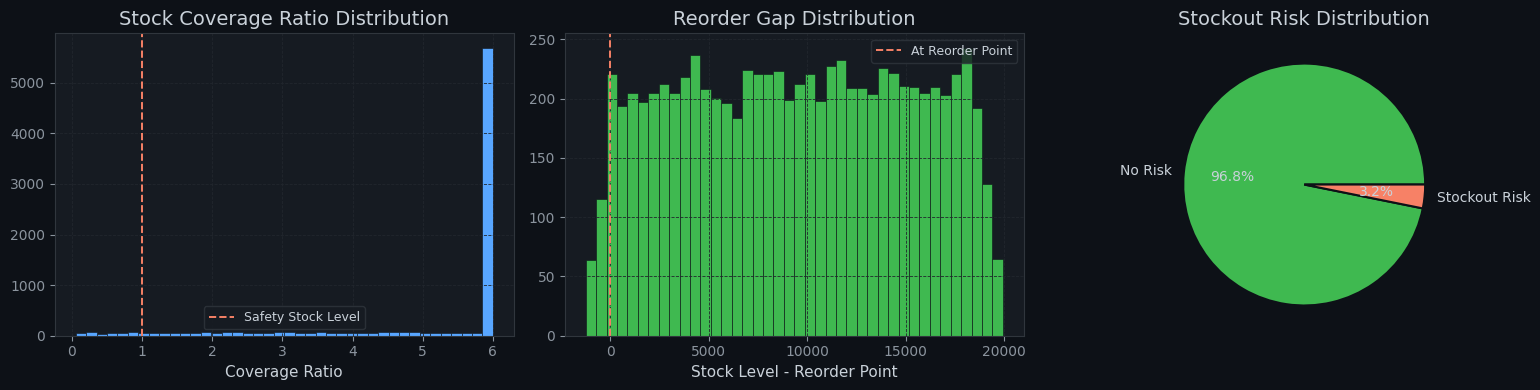

[Figure 1 - Inventory Feature Distributions]


In [10]:
# ── 3.3 Visualise inventory health distribution ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='#0D1117')

axes[0].hist(inv['stock_coverage_ratio'].clip(0, 6), bins=40,
             color='#58A6FF', edgecolor='#0D1117', linewidth=0.4)
axes[0].axvline(1, color='#F78166', linestyle='--', linewidth=1.4,
                label='Safety Stock Level')
axes[0].set_title('Stock Coverage Ratio Distribution')
axes[0].set_xlabel('Coverage Ratio')
axes[0].legend()

axes[1].hist(inv['reorder_gap'], bins=40,
             color='#3FB950', edgecolor='#0D1117', linewidth=0.4)
axes[1].axvline(0, color='#F78166', linestyle='--', linewidth=1.4,
                label='At Reorder Point')
axes[1].set_title('Reorder Gap Distribution')
axes[1].set_xlabel('Stock Level - Reorder Point')
axes[1].legend()

stockout_counts = inv['stockout_risk_flag'].value_counts()
axes[2].pie(
    stockout_counts,
    labels=['No Risk','Stockout Risk'],
    autopct='%1.1f%%',
    colors=['#3FB950','#F78166'],
    textprops={'color': '#C9D1D9'},
    wedgeprops={'edgecolor': '#0D1117', 'linewidth': 1.5}
)
axes[2].set_title('Stockout Risk Distribution')

plt.tight_layout()
plt.show()
print('[Figure 1 - Inventory Feature Distributions]')

---
## 4. Procurement Features
Procurement features capture supplier cost efficiency, delivery performance, and order-level quality metrics critical for cost prediction models.

In [11]:
# ── 4.1 Cost efficiency features ────────────

# Unit Cost Premium: how much more / less we pay vs standard product unit cost
proc['unit_cost_premium']   = inv['unit_cost'] - proc['unit_cost_y']
proc['unit_cost_premium_pct'] = proc['unit_cost_premium'] / (proc['unit_cost_y'] + 1e-9) * 100

# Procurement Efficiency Ratio = actual cost / ideal cost
# > 1 = overpaying; < 1 = negotiated discount
proc['ideal_cost']            = proc['order_quantity'] * proc['unit_cost_y']
proc['cost_efficiency_ratio'] = proc['total_cost'] / (proc['ideal_cost'] + 1e-9)
proc['volume_discount_flag']  = (proc['cost_efficiency_ratio'] < 1).astype(int)

# Cost per unit ordered
proc['actual_cost_per_unit']  = proc['total_cost'] / (proc['order_quantity'] + 1e-9)

print('Procurement cost features created.')
proc[['unit_cost_premium','unit_cost_premium_pct','cost_efficiency_ratio',
      'volume_discount_flag','actual_cost_per_unit']].describe()

Procurement cost features created.


,unit_cost_premium,unit_cost_premium_pct,cost_efficiency_ratio,volume_discount_flag,actual_cost_per_unit
count,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000
mean,16.5192,77.7330,1.7547,0.4873,1009.7774
std,720.1450,221.7168,2.2474,0.4999,569.3553
min,-1630.8300,-91.7909,0.0060,0.0000,10.6384
25%,-480.3400,-41.3204,0.5399,0.0000,524.7104
50%,0.0000,0.0000,1.0288,0.0000,1001.4238
75%,497.2500,72.2136,1.7989,1.0000,1498.1966
max,1630.8300,1118.1556,13.6508,1.0000,1999.6199


In [12]:
# ── 4.2 Lead time features ───────────────────
supplier_lead = proc.groupby('supplier_id')['lead_time_days'].agg(
    supplier_avg_lead_time='mean',
    supplier_std_lead_time='std',
    supplier_max_lead_time='max',
    supplier_min_lead_time='min'
).reset_index()
supplier_lead['supplier_std_lead_time'] = supplier_lead['supplier_std_lead_time'].fillna(0)
proc = proc.merge(supplier_lead, on='supplier_id', how='left')

# Lead Time Coefficient of Variation
proc['lead_time_cv'] = (
    proc['supplier_std_lead_time'] / (proc['supplier_avg_lead_time'] + 1e-9)
)

# Lead time z-score vs supplier average
proc['lead_time_zscore'] = (
    (proc['lead_time_days'] - proc['supplier_avg_lead_time']) /
    (proc['supplier_std_lead_time'] + 1e-9)
)

# Late delivery flag
proc['late_delivery_flag'] = (
    proc['lead_time_days'] > proc['supplier_avg_lead_time']
).astype(int)

print('Lead time features created.')
proc[['lead_time_days','supplier_avg_lead_time','lead_time_cv',
      'lead_time_zscore','late_delivery_flag']].describe()

Lead time features created.


,lead_time_days,supplier_avg_lead_time,lead_time_cv,lead_time_zscore,late_delivery_flag
count,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000
mean,30.8573,30.8573,0.5323,0.0000,0.5047
std,16.4130,0.9320,0.0262,0.9985,0.5001
min,2.0000,28.9555,0.4937,-1.8998,0.0000
25%,17.0000,30.3303,0.5041,-0.8433,0.0000
50%,31.0000,30.5809,0.5443,0.0193,1.0000
75%,45.0000,31.6971,0.5583,0.8643,1.0000
max,59.0000,32.2021,0.5629,1.8560,1.0000


In [13]:
# ── 4.3 Supplier Reliability Index (SRI) ────
# SRI = (quality_score / 100) x (1 - normalised_lead_time_cv)
cv_min = proc['lead_time_cv'].min()
cv_max = proc['lead_time_cv'].max()
proc['lead_time_cv_norm'] = (proc['lead_time_cv'] - cv_min) / (cv_max - cv_min + 1e-9)

proc['supplier_reliability_index'] = (
    (proc['quality_score'] / 100) * (1 - proc['lead_time_cv_norm'])
).round(4)

# Supplier-level average SRI for use in other tables
supplier_sri = proc.groupby('supplier_id')['supplier_reliability_index'].mean().reset_index()
supplier_sri.columns = ['supplier_id','avg_supplier_reliability_index']

print('Supplier Reliability Index created.')
proc[['supplier_id','quality_score','lead_time_cv','supplier_reliability_index']].describe()

Supplier Reliability Index created.


,supplier_id,quality_score,lead_time_cv,supplier_reliability_index
count,3000.0000,3000.0000,3000.0000,3000.0000
mean,5.4867,85.2426,0.5323,0.3767
std,2.8532,8.7433,0.0262,0.3259
min,1.0000,70.0119,0.4937,0.0000
25%,3.0000,77.4446,0.5041,0.0558
50%,6.0000,85.4902,0.5443,0.2619
75%,8.0000,93.0516,0.5583,0.7048
max,10.0000,99.9860,0.5629,0.9976


In [14]:
# ── 4.4 Order size & seasonality features ───
proc['order_size_category'] = pd.cut(
    proc['order_quantity'],
    bins=[0, 100, 500, 2000, np.inf],
    labels=['Small','Medium','Large','Bulk']
)

monthly_spend = proc.groupby(
    ['supplier_id','ord_year','ord_month'])['total_cost'].sum().reset_index()
monthly_spend.columns = ['supplier_id','ord_year','ord_month','monthly_supplier_spend']
proc = proc.merge(monthly_spend, on=['supplier_id','ord_year','ord_month'], how='left')

q_spend = proc.groupby(
    ['supplier_id','ord_year','ord_quarter'])['total_cost'].mean().reset_index()
q_spend.columns = ['supplier_id','ord_year','ord_quarter','q_avg_cost']
proc = proc.merge(q_spend, on=['supplier_id','ord_year','ord_quarter'], how='left')

print('Order size & seasonality features created.')
proc['order_size_category'].value_counts()

Order size & seasonality features created.


order_size_category
Bulk      1824
Large      944
Medium     230
Small        2
Name: count, dtype: int64

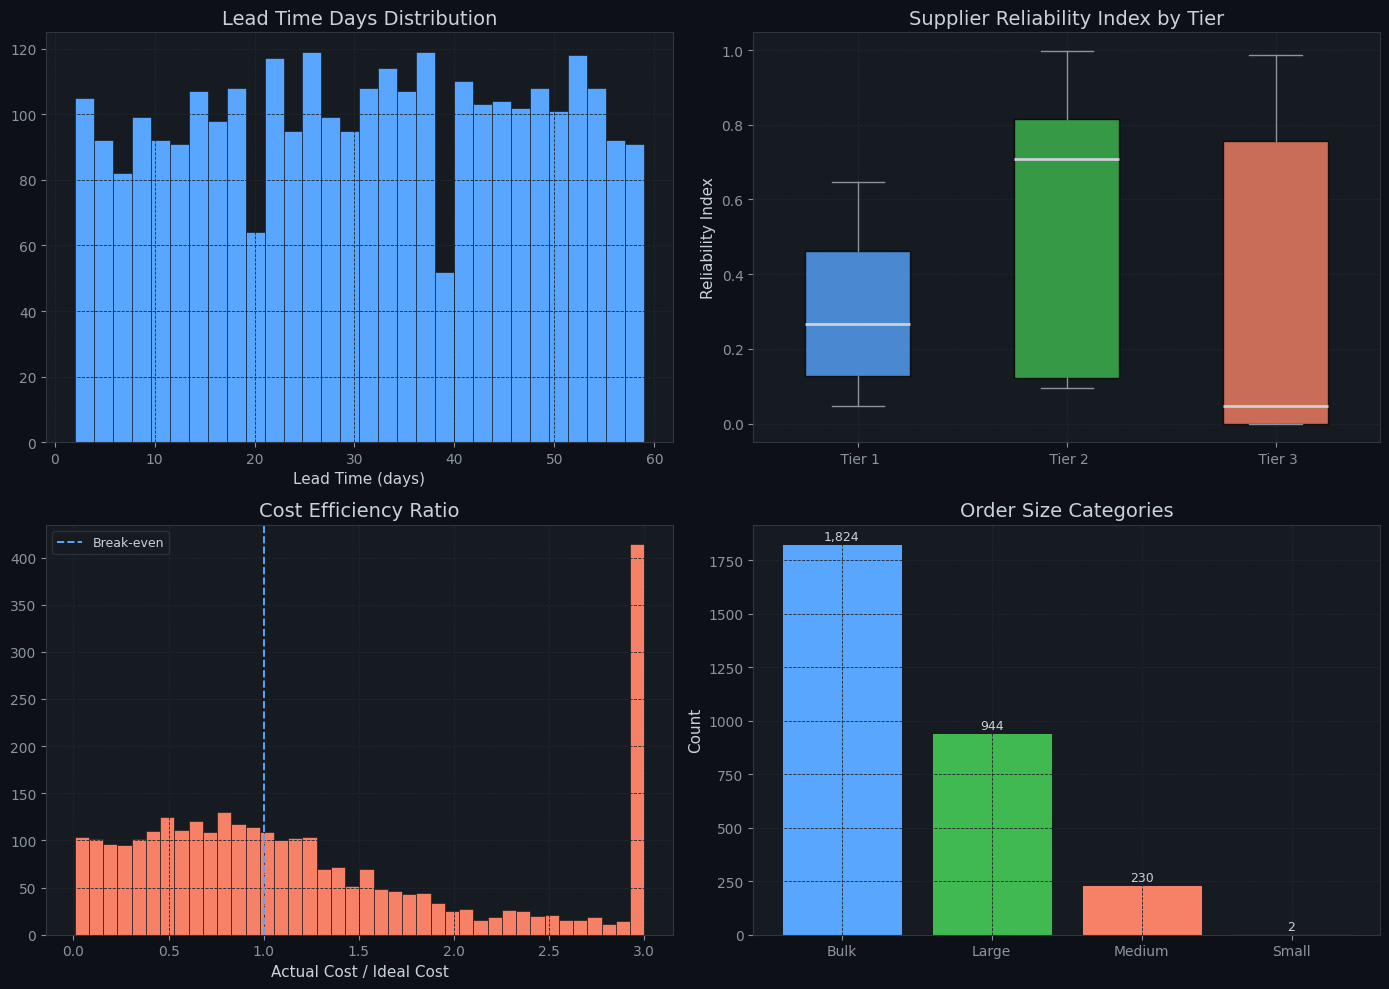

[Figure 2 - Procurement Feature Distributions]


In [15]:
# ── 4.5 Visualise procurement features ──────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0D1117')

axes[0,0].hist(proc['lead_time_days'], bins=30,
               color='#58A6FF', edgecolor='#0D1117', linewidth=0.4)
axes[0,0].set_title('Lead Time Days Distribution')
axes[0,0].set_xlabel('Lead Time (days)')

tiers = proc['tier'].dropna().unique()
for i, tier in enumerate(sorted(tiers)):
    data = proc[proc['tier'] == tier]['supplier_reliability_index'].dropna()
    axes[0,1].boxplot(data, positions=[i], widths=0.5,
                      patch_artist=True,
                      boxprops=dict(facecolor=DARK_PALETTE[i % len(DARK_PALETTE)], alpha=0.8),
                      medianprops=dict(color='#C9D1D9', linewidth=2),
                      whiskerprops=dict(color='#8B949E'),
                      capprops=dict(color='#8B949E'),
                      flierprops=dict(marker='o', color='#8B949E', markersize=3))
axes[0,1].set_xticks(range(len(sorted(tiers))))
axes[0,1].set_xticklabels(sorted(tiers))
axes[0,1].set_title('Supplier Reliability Index by Tier')
axes[0,1].set_ylabel('Reliability Index')

axes[1,0].hist(proc['cost_efficiency_ratio'].clip(0, 3), bins=40,
               color='#F78166', edgecolor='#0D1117', linewidth=0.4)
axes[1,0].axvline(1, color='#58A6FF', linestyle='--', linewidth=1.4, label='Break-even')
axes[1,0].set_title('Cost Efficiency Ratio')
axes[1,0].set_xlabel('Actual Cost / Ideal Cost')
axes[1,0].legend()

order_cat = proc['order_size_category'].value_counts()
bars = axes[1,1].bar(order_cat.index, order_cat.values,
                     color=DARK_PALETTE[:len(order_cat)],
                     edgecolor='#0D1117', linewidth=0.6)
for bar, val in zip(bars, order_cat.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{val:,}', ha='center', va='bottom', fontsize=9, color='#C9D1D9')
axes[1,1].set_title('Order Size Categories')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('[Figure 2 - Procurement Feature Distributions]')

---
## 5. Production Features
Production features focus on quality yield, defect patterns, and facility utilisation — key for predicting defect occurrence.

In [16]:
# ── 5.1 Yield & defect features ──────────────

# Production Yield Ratio: good units as a fraction of total units produced
prod['production_yield_ratio'] = (
    (prod['quantity_produced'] - prod['defective_units']) /
    (prod['quantity_produced'] + 1e-9)
).clip(0, 1)

prod['good_units'] = prod['quantity_produced'] - prod['defective_units']

# Defect severity banding
prod['defect_severity'] = pd.cut(
    prod['defect_rate_pct'],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=['Excellent','Good','Warning','Critical']
)

# Binary classification target for defect prediction
prod['high_defect_flag'] = (prod['defect_rate_pct'] > 5).astype(int)

prod['production_value'] = prod['good_units'] * prod['unit_cost']
prod['waste_cost']       = prod['defective_units'] * prod['unit_cost']

print('Production yield & defect features created.')
prod[['production_yield_ratio','defect_rate_pct','high_defect_flag',
      'production_value','waste_cost']].describe()

Production yield & defect features created.


,production_yield_ratio,defect_rate_pct,high_defect_flag,production_value,waste_cost
count,9000.0000,9000.0000,9000.0000,9000.0000,9000.0000
mean,0.9401,6.6376,0.2456,9526174.0567,242706.9009
std,0.1260,19.5314,0.4304,8080930.6512,204968.4797
min,0.0000,0.0000,0.0000,-572090.9600,0.0000
25%,0.9510,1.2478,0.0000,2616402.0525,66653.4500
50%,0.9752,2.4763,0.0000,7571748.2600,192165.9600
75%,0.9875,4.9010,0.0000,14629069.5000,370637.4075
max,1.0000,392.2330,1.0000,35014809.4400,884786.6400


In [17]:
# ── 5.2 Facility performance features ───────
prod['facility_capacity_util'] = prod['quantity_produced'] / (prod['annual_capacity'] + 1e-9)

prod_sorted = prod.sort_values(['facility_id','date_key'])
prod_sorted['facility_defect_rolling_avg'] = (
    prod_sorted.groupby('facility_id')['defect_rate_pct']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
# Positive = worsening trend; negative = improving
prod_sorted['defect_trend'] = (
    prod_sorted['defect_rate_pct'] - prod_sorted['facility_defect_rolling_avg']
)

facility_yield = prod_sorted.groupby('facility_id')['production_yield_ratio'].mean().reset_index()
facility_yield.columns = ['facility_id','facility_avg_yield']
prod = prod_sorted.merge(facility_yield, on='facility_id', how='left')

print('Facility performance features created.')
prod[['facility_capacity_util','facility_defect_rolling_avg',
      'defect_trend','facility_avg_yield']].describe()

Facility performance features created.


,facility_capacity_util,facility_defect_rolling_avg,defect_trend,facility_avg_yield
count,9000.0000,9000.0000,9000.0000,9000.0000
mean,0.0321,6.6375,0.0000,0.9401
std,0.0197,11.3285,15.9234,0.0022
min,0.0002,0.1105,-131.2591,0.9366
25%,0.0155,2.0973,-2.1745,0.9386
50%,0.0312,3.3537,-0.3727,0.9417
75%,0.0461,6.3993,1.2457,0.9417
max,0.0842,137.1472,259.3446,0.9419


In [18]:
# ── 5.3 Product-level defect benchmark 
product_defect_avg = prod.groupby('product_id')['defect_rate_pct'].mean().reset_index()
product_defect_avg.columns = ['product_id','product_avg_defect_rate']
prod = prod.merge(product_defect_avg, on='product_id', how='left')

# Positive = worse than that product's historical average
prod['defect_deviation_from_product_avg'] = (
    prod['defect_rate_pct'] - prod['product_avg_defect_rate']
)

print('Product defect benchmark features created.')

Product defect benchmark features created.


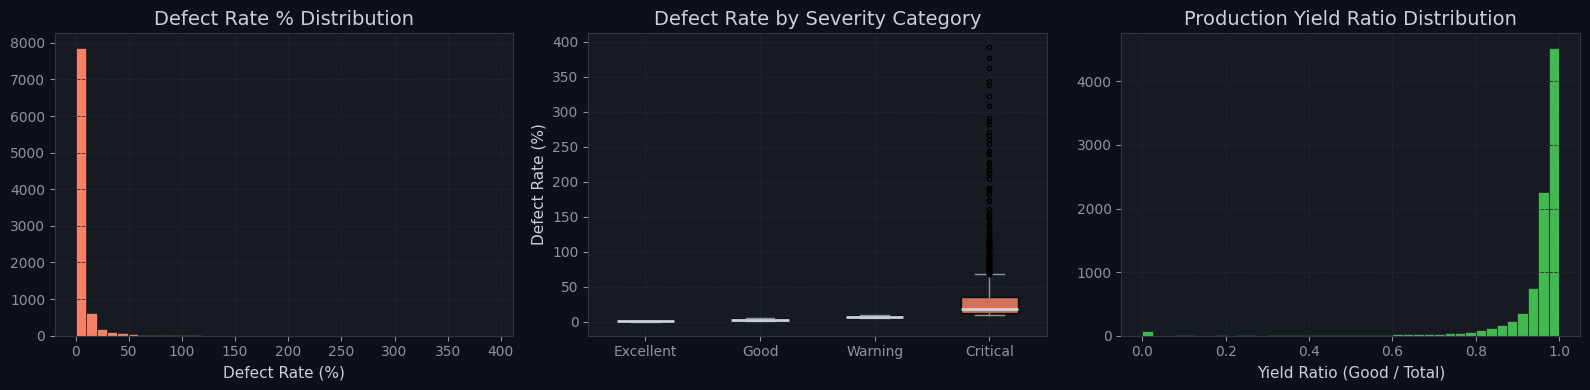

[Figure 3 - Production Feature Distributions]


In [19]:
# ── 5.4 Visualise production features 
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='#0D1117')

axes[0].hist(prod['defect_rate_pct'], bins=40,
             color='#F78166', edgecolor='#0D1117', linewidth=0.4)
axes[0].set_title('Defect Rate % Distribution')
axes[0].set_xlabel('Defect Rate (%)')

severity_order  = ['Excellent','Good','Warning','Critical']
severity_colors = ['#3FB950','#58A6FF','#FFA657','#F78166']
for i, sev in enumerate(severity_order):
    data = prod[prod['defect_severity'] == sev]['defect_rate_pct'].dropna()
    if len(data):
        axes[1].boxplot(data, positions=[i], widths=0.5,
                        patch_artist=True,
                        boxprops=dict(facecolor=severity_colors[i], alpha=0.85),
                        medianprops=dict(color='#C9D1D9', linewidth=2),
                        whiskerprops=dict(color='#8B949E'),
                        capprops=dict(color='#8B949E'),
                        flierprops=dict(marker='o', color='#8B949E', markersize=3))
axes[1].set_xticks(range(len(severity_order)))
axes[1].set_xticklabels(severity_order)
axes[1].set_title('Defect Rate by Severity Category')
axes[1].set_ylabel('Defect Rate (%)')

axes[2].hist(prod['production_yield_ratio'], bins=40,
             color='#3FB950', edgecolor='#0D1117', linewidth=0.4)
axes[2].set_title('Production Yield Ratio Distribution')
axes[2].set_xlabel('Yield Ratio (Good / Total)')

plt.tight_layout()
plt.show()
print('[Figure 3 - Production Feature Distributions]')

---
## 6. Sales & Profitability Features
These features capture revenue quality, discount impact, and customer-level profitability — inputs for profit margin regression.

In [20]:
# ── 6.1 Core profitability features 
sales['gross_margin_per_unit']     = proc['unit_price'] - prod['unit_cost']
sales['gross_margin_pct']          = (
    sales['gross_margin_per_unit'] / (proc['unit_price'] + 1e-9) * 100
)
# Revenue Realisation Ratio: net / gross (measures discount erosion)
sales['revenue_realisation_ratio'] = sales['net_revenue'] / (sales['gross_revenue'] + 1e-9)
sales['discount_impact_usd']       = sales['gross_revenue'] - sales['net_revenue']
sales['profit_per_unit']           = sales['profit'] / (sales['quantity_sold'] + 1e-9)
sales['revenue_per_unit']          = sales['net_revenue'] / (sales['quantity_sold'] + 1e-9)

# Binary classification target
sales['high_profit_flag'] = (
    sales['profit_margin_pct'] > sales['profit_margin_pct'].median()
).astype(int)

print('Sales profitability features created.')
sales[['gross_margin_pct','revenue_realisation_ratio','discount_impact_usd',
       'profit_per_unit','high_profit_flag']].describe()

Sales profitability features created.


,gross_margin_pct,revenue_realisation_ratio,discount_impact_usd,profit_per_unit,high_profit_flag
count,3000.0000,150000.0000,150000.0000,150000.0000,150000.0000
mean,-111.9246,0.9979,191.2992,507.0186,0.5000
std,406.7884,0.0098,164.8339,328.1730,0.5000
min,-2696.6000,0.7003,0.0011,-178.4460,0.0000
25%,-85.8471,0.9988,55.3198,238.7673,0.0000
50%,20.3646,0.9994,144.9263,460.1812,0.5000
75%,61.3031,0.9997,290.0184,725.0691,1.0000
max,94.0900,1.0000,741.9526,1492.4884,1.0000


In [21]:
# ── 6.2 Customer Profitability Index (CPI) 
customer_profit = sales.groupby('customer_id').agg(
    cust_total_revenue   = ('net_revenue',       'sum'),
    cust_total_profit    = ('profit',             'sum'),
    cust_avg_margin      = ('profit_margin_pct',  'mean'),
    cust_avg_discount    = ('discount_pct',        'mean'),
    cust_order_count     = ('sales_id',            'count'),
    cust_avg_order_value = ('net_revenue',         'mean'),
).reset_index()

# CPI = total_profit / total_revenue
customer_profit['customer_profitability_index'] = (
    customer_profit['cust_total_profit'] / (customer_profit['cust_total_revenue'] + 1e-9)
)

sales = sales.merge(
    customer_profit[['customer_id','cust_total_revenue','cust_avg_margin',
                     'cust_avg_discount','cust_order_count',
                     'customer_profitability_index']],
    on='customer_id', how='left'
)

print('Customer Profitability Index created.')
customer_profit[['customer_profitability_index','cust_avg_margin','cust_order_count']].describe()

Customer Profitability Index created.


,customer_profitability_index,cust_avg_margin,cust_order_count
count,5.0000,5.0000,5.0000
mean,0.3994,39.8441,30000.0000
std,0.0004,0.0731,106.0943
min,0.3988,39.7824,29855.0000
25%,0.3994,39.8162,29942.0000
50%,0.3995,39.8183,30027.0000
75%,0.3996,39.8327,30041.0000
max,0.3999,39.9707,30135.0000


In [22]:
# ── 6.3 Product revenue contribution & channel profitability ─────────────────
product_revenue = sales.groupby('product_id').agg(
    prod_total_revenue = ('net_revenue',      'sum'),
    prod_total_profit  = ('profit',           'sum'),
    prod_units_sold    = ('quantity_sold',     'sum'),
    prod_avg_margin    = ('profit_margin_pct', 'mean'),
).reset_index()

product_revenue['product_revenue_share'] = (
    product_revenue['prod_total_revenue'] / product_revenue['prod_total_revenue'].sum()
)

sales = sales.merge(
    product_revenue[['product_id','prod_total_revenue',
                     'prod_avg_margin','product_revenue_share']],
    on='product_id', how='left'
)

channel_profit = sales.groupby('channel_type')['profit_margin_pct'].mean().reset_index()
channel_profit.columns = ['channel_type','channel_avg_margin']
sales = sales.merge(channel_profit, on='channel_type', how='left')

print('Product & channel revenue features created.')

Product & channel revenue features created.


[Figure 4 - Sales Feature Distributions]


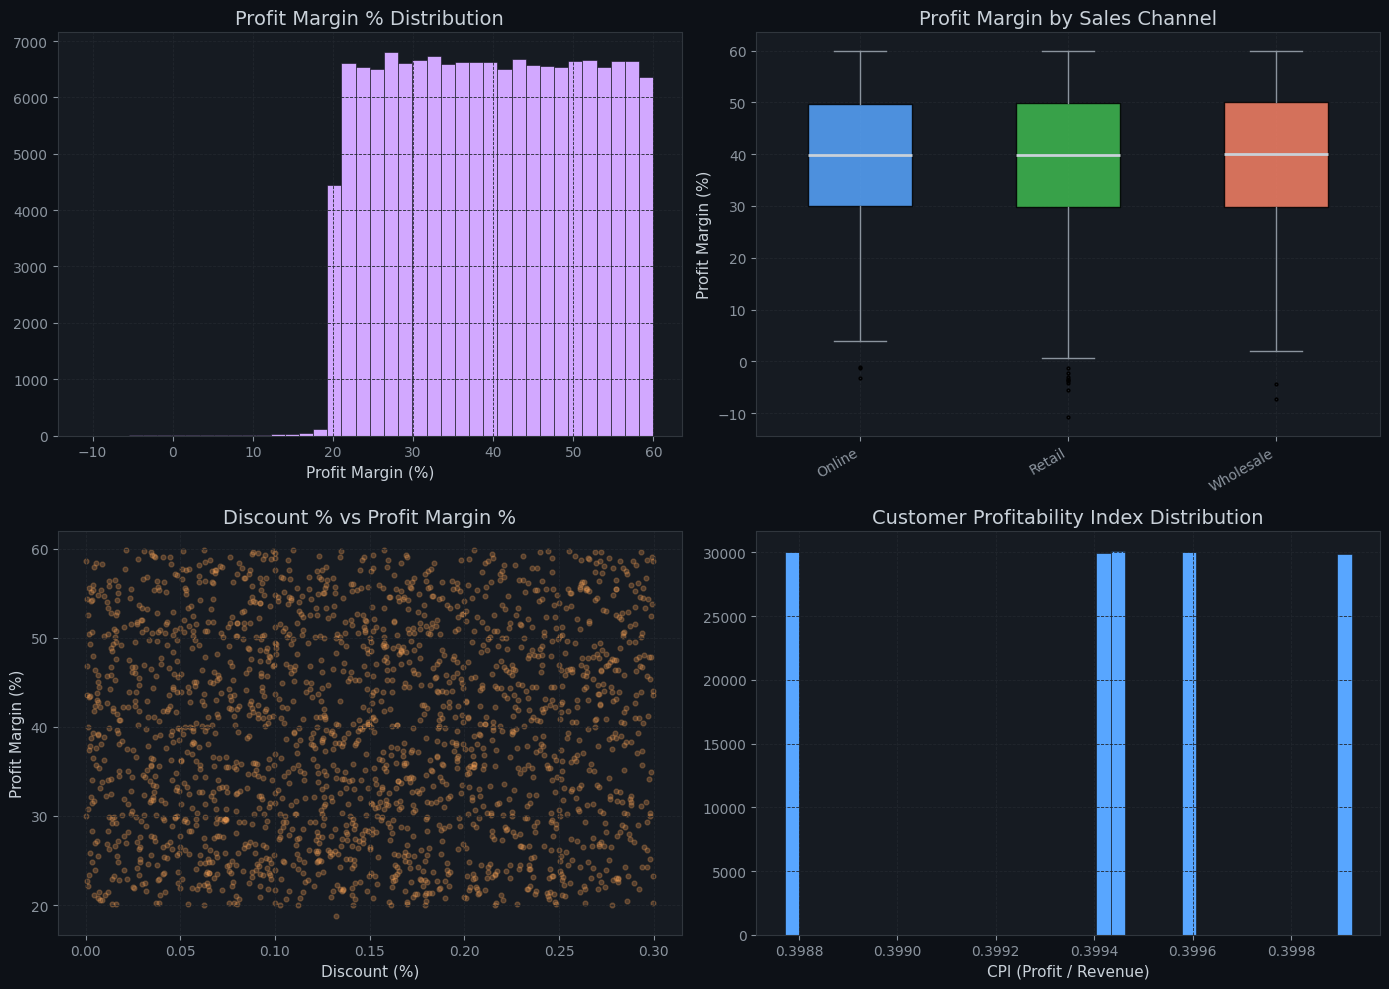

In [23]:
# ── 6.4 Visualise sales features 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0D1117')

axes[0,0].hist(sales['profit_margin_pct'], bins=40,
               color='#D2A8FF', edgecolor='#0D1117', linewidth=0.4)
axes[0,0].set_title('Profit Margin % Distribution')
axes[0,0].set_xlabel('Profit Margin (%)')

channels = sales['channel_type'].dropna().unique()
for i, ch in enumerate(sorted(channels)):
    data = sales[sales['channel_type'] == ch]['profit_margin_pct'].dropna()
    axes[0,1].boxplot(data, positions=[i], widths=0.5,
                      patch_artist=True,
                      boxprops=dict(facecolor=DARK_PALETTE[i % len(DARK_PALETTE)], alpha=0.85),
                      medianprops=dict(color='#C9D1D9', linewidth=2),
                      whiskerprops=dict(color='#8B949E'),
                      capprops=dict(color='#8B949E'),
                      flierprops=dict(marker='o', color='#8B949E', markersize=2))
axes[0,1].set_xticks(range(len(sorted(channels))))
axes[0,1].set_xticklabels(sorted(channels), rotation=30, ha='right')
axes[0,1].set_title('Profit Margin by Sales Channel')
axes[0,1].set_ylabel('Profit Margin (%)')

sample = sales.sample(min(2000, len(sales)))
axes[1,0].scatter(sample['discount_pct'], sample['profit_margin_pct'],
                  alpha=0.25, color='#FFA657', s=12)
axes[1,0].set_title('Discount % vs Profit Margin %')
axes[1,0].set_xlabel('Discount (%)')
axes[1,0].set_ylabel('Profit Margin (%)')

axes[1,1].hist(sales['customer_profitability_index'], bins=40,
               color='#58A6FF', edgecolor='#0D1117', linewidth=0.4)
axes[1,1].set_title('Customer Profitability Index Distribution')
axes[1,1].set_xlabel('CPI (Profit / Revenue)')

plt.tight_layout()
print('[Figure 4 - Sales Feature Distributions]')

---
## 7. Shipment & Logistics Features
Logistics features power the shipment delay classifier — the most important classification target in this project.

In [24]:
# ── 7.1 Transit time & delay features 
ship['transit_days'] = ship['delivery_date_key'] - ship['ship_date_key']

# Binary delay target from status field
ship['is_delayed'] = (
    ship['status'].str.lower().str.contains('delay|late', na=False)
).astype(int)

carrier_transit = ship.groupby('carrier')['transit_days'].agg(
    carrier_avg_transit='mean',
    carrier_std_transit='std',
    carrier_delay_rate=lambda x: (x > x.mean()).mean()
).reset_index()
carrier_transit['carrier_std_transit'] = carrier_transit['carrier_std_transit'].fillna(0)
ship = ship.merge(carrier_transit, on='carrier', how='left')

ship['transit_deviation']     = ship['transit_days'] - ship['carrier_avg_transit']
ship['transit_deviation_pct'] = (
    ship['transit_deviation'] / (ship['carrier_avg_transit'] + 1e-9) * 100
)

print('Transit time & delay features created.')
ship[['transit_days','is_delayed','carrier_avg_transit','transit_deviation']].describe()

Transit time & delay features created.


,transit_days,is_delayed,carrier_avg_transit,transit_deviation
count,12000.0000,12000.0000,12000.0000,12000.0000
mean,11.2626,0.3345,11.2626,0.0000
std,894.5804,0.4718,11.2130,894.5101
min,-2154.0000,0.0000,-7.3440,-2169.1451
25%,-635.0000,0.0000,13.5644,-646.6560
50%,6.0000,0.0000,15.1451,-2.8548
75%,652.0000,1.0000,15.1451,641.3440
max,2171.0000,1.0000,23.2295,2148.4356


In [25]:
# ── 7.2 Shipping cost features 
ship['cost_per_kg']           = ship['shipping_cost'] / (ship['total_weight_kg'] + 1e-9)
ship['cost_per_unit_shipped'] = ship['shipping_cost'] / (ship['quantity'] + 1e-9)

carrier_cost = ship.groupby('carrier')['cost_per_kg'].mean().reset_index()
carrier_cost.columns = ['carrier','carrier_avg_cost_per_kg']
ship = ship.merge(carrier_cost, on='carrier', how='left')

ship['cost_premium_vs_carrier'] = ship['cost_per_kg'] - ship['carrier_avg_cost_per_kg']

ship['shipment_size_cat'] = pd.cut(
    ship['quantity'],
    bins=[0, 50, 200, 1000, np.inf],
    labels=['Small','Medium','Large','Bulk']
)

print('Shipping cost features created.')
ship[['cost_per_kg','cost_per_unit_shipped',
      'carrier_delay_rate','cost_premium_vs_carrier']].describe()

Shipping cost features created.


,cost_per_kg,cost_per_unit_shipped,carrier_delay_rate,cost_premium_vs_carrier
count,12000.0000,12000.0000,12000.0000,12000.0000
mean,1.5311,2.3717,0.4984,0.0000
std,5.3741,5.5407,0.0020,5.3741
min,0.0052,0.0115,0.4960,-1.5475
25%,0.2612,0.5118,0.4971,-1.2703
50%,0.5104,1.0044,0.4971,-1.0203
75%,1.0191,1.9513,0.4995,-0.5121
max,138.5680,86.4838,0.5012,137.0131


In [26]:
# ── 7.3 Route & destination features ────────
ship['route']           = ship['facility_country'].astype(str) + '_to_' + ship['country'].astype(str)
ship['is_international']= (ship['facility_country'] != ship['country']).astype(int)
ship['has_delay_reason']= ship['delay_reason'].notna().astype(int)

route_delay = ship.groupby('route')['is_delayed'].mean().reset_index()
route_delay.columns = ['route','route_delay_rate']
ship = ship.merge(route_delay, on='route', how='left')

cust_delay = ship.groupby('customer_id')['is_delayed'].agg(
    cust_delay_count='sum',
    cust_delay_rate='mean'
).reset_index()
ship = ship.merge(cust_delay, on='customer_id', how='left')

print('Route & destination features created.')
ship[['is_international','route_delay_rate','cust_delay_rate','has_delay_reason']].describe()

Route & destination features created.


,is_international,route_delay_rate,cust_delay_rate,has_delay_reason
count,12000.0000,12000.0000,12000.0000,12000.0000
mean,0.0000,0.3345,0.3345,1.0000
std,0.0000,0.0000,0.0024,0.0000
min,0.0000,0.3345,0.3311,1.0000
25%,0.0000,0.3345,0.3326,1.0000
50%,0.0000,0.3345,0.3343,1.0000
75%,0.0000,0.3345,0.3370,1.0000
max,0.0000,0.3345,0.3374,1.0000


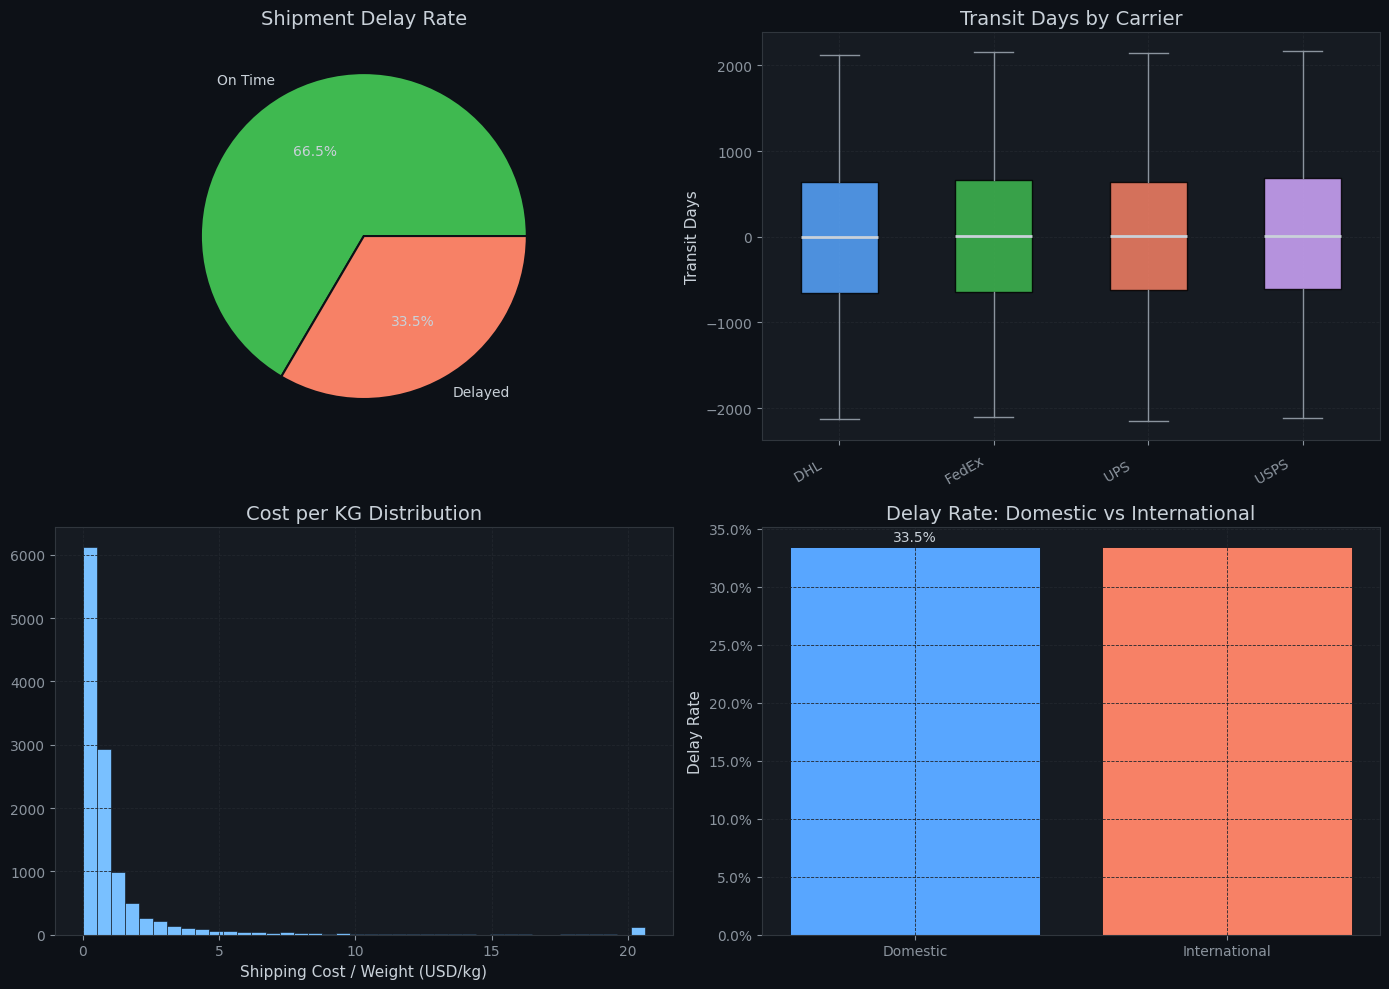

[Figure 5 - Shipment Feature Distributions]


In [27]:
# ── 7.4 Visualise shipment features ─────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0D1117')

delay_counts = ship['is_delayed'].value_counts()
axes[0,0].pie(
    delay_counts,
    labels=['On Time','Delayed'],
    autopct='%1.1f%%',
    colors=['#3FB950','#F78166'],
    textprops={'color': '#C9D1D9'},
    wedgeprops={'edgecolor': '#0D1117', 'linewidth': 1.5}
)
axes[0,0].set_title('Shipment Delay Rate')

carriers = ship['carrier'].dropna().unique()
for i, carrier in enumerate(sorted(carriers)):
    data = ship[ship['carrier'] == carrier]['transit_days'].dropna()
    axes[0,1].boxplot(data, positions=[i], widths=0.5,
                      patch_artist=True,
                      boxprops=dict(facecolor=DARK_PALETTE[i % len(DARK_PALETTE)], alpha=0.85),
                      medianprops=dict(color='#C9D1D9', linewidth=2),
                      whiskerprops=dict(color='#8B949E'),
                      capprops=dict(color='#8B949E'),
                      flierprops=dict(marker='o', color='#8B949E', markersize=3))
axes[0,1].set_xticks(range(len(sorted(carriers))))
axes[0,1].set_xticklabels(sorted(carriers), rotation=30, ha='right')
axes[0,1].set_title('Transit Days by Carrier')
axes[0,1].set_ylabel('Transit Days')

q99 = ship['cost_per_kg'].quantile(0.99)
axes[1,0].hist(ship['cost_per_kg'].clip(0, q99), bins=40,
               color='#79C0FF', edgecolor='#0D1117', linewidth=0.4)
axes[1,0].set_title('Cost per KG Distribution')
axes[1,0].set_xlabel('Shipping Cost / Weight (USD/kg)')

intl_delay = ship.groupby('is_international')['is_delayed'].mean()
bars = axes[1,1].bar(['Domestic','International'], intl_delay.values,
                     color=['#58A6FF','#F78166'],
                     edgecolor='#0D1117', linewidth=0.6)
for bar, val in zip(bars, intl_delay.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                   f'{val:.1%}', ha='center', va='bottom', fontsize=10, color='#C9D1D9')
axes[1,1].set_title('Delay Rate: Domestic vs International')
axes[1,1].set_ylabel('Delay Rate')
axes[1,1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()
print('[Figure 5 - Shipment Feature Distributions]')

---
## 8. Supplier-Level Aggregated Features
Aggregate all fact tables to supplier level for supplier segmentation (clustering) and regression inputs.

In [28]:
# ── 8.1 Build supplier profile table 
supplier_profile = proc.groupby('supplier_id').agg(
    total_orders             = ('procurement_id',           'count'),
    total_procurement_spend  = ('total_cost',               'sum'),
    avg_procurement_cost     = ('total_cost',               'mean'),
    avg_lead_time            = ('lead_time_days',           'mean'),
    std_lead_time            = ('lead_time_days',           'std'),
    avg_quality_score_proc   = ('quality_score',            'mean'),
    avg_reliability_index    = ('supplier_reliability_index','mean'),
    late_delivery_rate       = ('late_delivery_flag',       'mean'),
    avg_cost_efficiency      = ('cost_efficiency_ratio',    'mean'),
    total_quantity_ordered   = ('order_quantity',           'sum'),
    unit_cost_premium_avg    = ('unit_cost_premium_pct',    'mean'),
).reset_index()

supplier_profile['std_lead_time'] = supplier_profile['std_lead_time'].fillna(0)
supplier_profile = supplier_profile.merge(
    dim_supplier[['supplier_id','supplier_name','country',
                  'specialty','tier','avg_quality_score']],
    on='supplier_id', how='left'
)

print('Supplier profile built:', supplier_profile.shape)
supplier_profile.head()

Supplier profile built: (10, 17)


,supplier_id,total_orders,total_procurement_spend,avg_procurement_cost,avg_lead_time,std_lead_time,avg_quality_score_proc,avg_reliability_index,late_delivery_rate,avg_cost_efficiency,total_quantity_ordered,unit_cost_premium_avg,supplier_name,country,specialty,tier,avg_quality_score
0,1,303,851139860.4914,2809042.4439,30.5809,16.2046,85.3083,0.4065,0.4818,1.8941,814515,99.3194,Intel Corporation,USA,Assembly,Tier 1,82.1200
1,2,292,747158340.1018,2558761.4387,32.2021,15.8971,85.5942,0.8559,0.5171,1.5900,777245,56.8257,Foxconn Technology Group,USA,Chips,Tier 2,71.9500
2,3,303,780593432.9074,2576215.9502,31.1287,16.9432,85.8000,0.2303,0.5182,1.6428,756279,75.8425,Flex Ltd,USA,Packaging,Tier 1,77.6200
3,4,284,680326833.8205,2395517.0205,31.9437,16.5462,84.9708,0.5511,0.5141,1.7298,693159,63.2835,Jabil Inc,USA,Chips,Tier 1,77.4100
4,5,311,770734559.2393,2478246.1712,30.0096,16.8914,85.4759,0.0000,0.5048,1.8736,755676,87.2968,Pegatron Corporation,USA,Chips,Tier 3,90.8900


In [29]:
# ── 8.2 Composite Supplier Risk Score ───────
# Risk Score = 0 (low risk) to 1 (high risk)
# Weighted sum of: late delivery rate, lead time variability,
# inverse quality, and cost premium

supplier_profile['lead_time_cv_sup'] = (
    supplier_profile['std_lead_time'] / (supplier_profile['avg_lead_time'] + 1e-9)
)

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

supplier_profile['risk_late_delivery']    = minmax(supplier_profile['late_delivery_rate'])
supplier_profile['risk_lead_variability'] = minmax(supplier_profile['lead_time_cv_sup'])
supplier_profile['risk_quality']          = minmax(1 - supplier_profile['avg_quality_score_proc'] / 100)
supplier_profile['risk_cost_premium']     = minmax(supplier_profile['unit_cost_premium_avg'].clip(lower=0))

supplier_profile['supplier_risk_score'] = (
    0.35 * supplier_profile['risk_late_delivery'] +
    0.25 * supplier_profile['risk_lead_variability'] +
    0.25 * supplier_profile['risk_quality'] +
    0.15 * supplier_profile['risk_cost_premium']
)

print('Supplier risk score created.')
supplier_profile[['supplier_id','supplier_name','tier',
                   'avg_reliability_index','supplier_risk_score']]\
    .sort_values('supplier_risk_score', ascending=False).head(10)

Supplier risk score created.


,supplier_id,supplier_name,tier,avg_reliability_index,supplier_risk_score
7,8,Qualcomm Incorporated,Tier 3,0.0465,0.8519
4,5,Pegatron Corporation,Tier 3,0.0000,0.6556
2,3,Flex Ltd,Tier 1,0.2303,0.6127
6,7,Micron Technology Inc,Tier 3,0.8340,0.5930
3,4,Jabil Inc,Tier 1,0.5511,0.5706
5,6,Samsung Electronics America,Tier 2,0.1154,0.5258
9,10,Broadcom Inc,Tier 1,0.0560,0.4990
0,1,Intel Corporation,Tier 1,0.4065,0.4050
1,2,Foxconn Technology Group,Tier 2,0.8559,0.3866
8,9,Texas Instruments,Tier 2,0.7284,0.3660


---
## 9. Customer-Level Aggregated Features
Customer features support customer segmentation clustering and profit margin regression.

In [30]:
# ── 9.1 Customer sales profile 
customer_profile = sales.groupby('customer_id').agg(
    total_orders       = ('sales_id',          'count'),
    total_revenue      = ('net_revenue',        'sum'),
    total_profit       = ('profit',             'sum'),
    avg_profit_margin  = ('profit_margin_pct',  'mean'),
    avg_discount_pct   = ('discount_pct',        'mean'),
    avg_order_value    = ('net_revenue',         'mean'),
    total_units_bought = ('quantity_sold',       'sum'),
    distinct_products  = ('product_id',          'nunique'),
    revenue_std        = ('net_revenue',         'std'),
).reset_index()

customer_profile['revenue_std'] = customer_profile['revenue_std'].fillna(0)

# Customer LTV proxy = cumulative profit
customer_profile['customer_ltv'] = customer_profile['total_profit']

# Revenue Consistency: lower CoV = more predictable buyer
customer_profile['revenue_cov'] = (
    customer_profile['revenue_std'] / (customer_profile['avg_order_value'] + 1e-9)
)

# Product diversity index: unique products / total orders
customer_profile['product_diversity_index'] = (
    customer_profile['distinct_products'] / customer_profile['total_orders']
).clip(0, 1)

customer_profile = customer_profile.merge(
    dim_customer[['customer_id','customer_name','country',
                  'channel_type','size','annual_volume_usd']],
    on='customer_id', how='left'
)
customer_profile = customer_profile.merge(cust_delay, on='customer_id', how='left')

print('Customer profile built:', customer_profile.shape)
customer_profile.head()

Customer profile built: (5, 20)


,customer_id,total_orders,total_revenue,total_profit,avg_profit_margin,avg_discount_pct,avg_order_value,total_units_bought,distinct_products,revenue_std,customer_ltv,revenue_cov,product_diversity_index,customer_name,country,channel_type,size,annual_volume_usd,cust_delay_count,cust_delay_rate
0,1,30027,9572339799.1043,3817170078.8353,39.7824,0.1499,318791.0813,7510648,20,272920.6149,3817170078.8353,0.8561,0.0007,Walmart Inc,USA,Retail,Enterprise,1658637542,802,0.3374
1,2,29855,9469145725.5956,3786931930.9489,39.9707,0.1497,317171.1849,7460032,20,274000.9253,3786931930.9489,0.8639,0.0007,Costco Wholesale Corporation,USA,Wholesale,Enterprise,837846414,813,0.3343
2,3,30041,9521635262.4908,3804663198.7615,39.8183,0.1510,316954.6707,7494369,20,273296.8878,3804663198.7615,0.8623,0.0007,Target Corporation,USA,Retail,Large,2621218620,776,0.3326
3,4,30135,9647568630.2271,3853727329.5312,39.8327,0.1505,320144.9686,7576151,20,274374.4056,3853727329.5312,0.8570,0.0007,Home Depot Inc,USA,Retail,Large,2613451924,788,0.3311
4,5,29942,9536318418.0814,3808938519.1138,39.8162,0.1500,318493.0338,7484947,20,273067.5284,3808938519.1138,0.8574,0.0007,Best Buy Co Inc,USA,Online,Enterprise,720094950,835,0.3370


In [31]:
# ── 9.2 RFM Features (Recency, Frequency, Monetary) ──────────────────────────
recency = sales.groupby('customer_id')['date_key'].max().reset_index()
recency.columns = ['customer_id','last_purchase_date_key']
max_key = sales['date_key'].max()
recency['recency_days'] = max_key - recency['last_purchase_date_key']
customer_profile = customer_profile.merge(recency, on='customer_id', how='left')

# Quintile scoring: 5 = best, 1 = worst for each R, F, M dimension
for col, ascending in [('recency_days', True),
                        ('total_orders', False),
                        ('total_revenue', False)]:
    customer_profile[col+'_score'] = pd.qcut(
        customer_profile[col].rank(method='first'),
        q=5,
        labels=[1,2,3,4,5] if not ascending else [5,4,3,2,1]
    ).astype(int)

customer_profile['rfm_score'] = (
    customer_profile['recency_days_score'] +
    customer_profile['total_orders_score'] +
    customer_profile['total_revenue_score']
)

print('RFM features created.')
customer_profile[['rfm_score','recency_days','total_orders','total_revenue']].describe()

RFM features created.


,rfm_score,recency_days,total_orders,total_revenue
count,5.0000,5.0000,5.0000,5.0000
mean,9.0000,0.0000,30000.0000,9549401567.0998
std,3.0000,0.0000,106.0943,66230792.1702
min,6.0000,0.0000,29855.0000,9469145725.5956
25%,6.0000,0.0000,29942.0000,9521635262.4908
50%,9.0000,0.0000,30027.0000,9536318418.0814
75%,12.0000,0.0000,30041.0000,9572339799.1043
max,12.0000,0.0000,30135.0000,9647568630.2271


---
## 10. Product-Level Aggregated Features

In [32]:
# ── 10.1 Product demand & profitability 
product_profile = sales.groupby('product_id').agg(
    total_units_sold   = ('quantity_sold',     'sum'),
    total_revenue_prod = ('net_revenue',        'sum'),
    avg_margin_prod    = ('profit_margin_pct',  'mean'),
    demand_std         = ('quantity_sold',       'std'),
    avg_discount_prod  = ('discount_pct',        'mean'),
).reset_index()

product_profile['demand_std'] = product_profile['demand_std'].fillna(0)
product_profile['demand_volatility'] = (
    product_profile['demand_std'] /
    (product_profile['total_units_sold'] /
     product_profile['total_units_sold'].count() + 1e-9)
)

# ── 10.2 Inventory Turnover: units sold / avg stock ───────────────────────────
avg_stock = inv.groupby('product_id')['stock_level'].mean().reset_index()
avg_stock.columns = ['product_id','avg_stock_level']
product_profile = product_profile.merge(avg_stock, on='product_id', how='left')
product_profile['inventory_turnover'] = (
    product_profile['total_units_sold'] / (product_profile['avg_stock_level'] + 1e-9)
)

# ── 10.3 Product defect profile & pricing ───
product_profile = product_profile.merge(product_defect_avg, on='product_id', how='left')
product_profile = product_profile.merge(
    dim_product[['product_id','product_name','category','product_line',
                 'unit_price','unit_cost','weight_kg']],
    on='product_id', how='left'
)
product_profile['price_cost_ratio'] = (
    product_profile['unit_price'] / (product_profile['unit_cost'] + 1e-9)
)

print('Product profile built:', product_profile.shape)
product_profile[['inventory_turnover','product_avg_defect_rate',
                  'price_cost_ratio','demand_volatility']].describe()

Product profile built: (20, 17)


,inventory_turnover,product_avg_defect_rate,price_cost_ratio,demand_volatility
count,20.0000,20.0000,20.0000,20.0000
mean,184.7621,6.6407,1.9890,0.0015
std,5.6708,0.8542,2.0063,0.0000
min,175.1621,5.4649,0.0416,0.0015
25%,180.5995,6.0138,0.5212,0.0015
50%,184.5246,6.4959,1.6909,0.0015
75%,188.6505,7.2326,2.7085,0.0016
max,194.4871,8.2154,7.5623,0.0016


---
## 11. Facility-Level Aggregated Features

In [33]:
# ── 11.1 Facility production performance ────
facility_profile = prod.groupby('facility_id').agg(
    total_batches        = ('production_id',          'count'),
    total_units_produced = ('quantity_produced',      'sum'),
    total_defective      = ('defective_units',        'sum'),
    avg_defect_rate      = ('defect_rate_pct',        'mean'),
    avg_yield_ratio      = ('production_yield_ratio', 'mean'),
    total_waste_cost     = ('waste_cost',             'sum'),
).reset_index()

facility_profile['overall_defect_rate'] = (
    facility_profile['total_defective'] /
    (facility_profile['total_units_produced'] + 1e-9) * 100
)

# ── 11.2 Facility shipment performance 
fac_ship = ship.groupby('facility_id').agg(
    fac_total_shipments   = ('shipment_id',  'count'),
    fac_delay_rate        = ('is_delayed',    'mean'),
    fac_avg_shipping_cost = ('shipping_cost', 'mean'),
    fac_avg_transit_days  = ('transit_days',  'mean'),
).reset_index()

facility_profile = facility_profile.merge(fac_ship, on='facility_id', how='left')
facility_profile = facility_profile.merge(
    dim_facility[['facility_id','facility_name','country','facility_type',
                  'specialization','annual_capacity']],
    on='facility_id', how='left'
)

print('Facility profile built:', facility_profile.shape)
facility_profile.head()

Facility profile built: (5, 17)


,facility_id,total_batches,total_units_produced,total_defective,avg_defect_rate,avg_yield_ratio,total_waste_cost,overall_defect_rate,fac_total_shipments,fac_delay_rate,fac_avg_shipping_cost,fac_avg_transit_days,facility_name,country,facility_type,specialization,annual_capacity
0,1,1857,18566254,462380,7.0188,0.9366,454082360.2200,2.4904,2402,0.3351,507.2376,36.1149,Chicago Distribution Center,USA,Manufacturing,Electronics,287337
1,2,1813,17881634,446727,6.4234,0.9419,430408403.6500,2.4982,2361,0.3448,506.1511,-9.4193,Houston Distribution Center,USA,Warehouse,Appliances,237498
2,3,1783,17511685,436848,7.2472,0.9386,423649983.8700,2.4946,2347,0.3349,500.8755,5.4913,Los Angeles Distribution Center,USA,Manufacturing,Furniture,325203
3,4,1736,17681836,440896,6.3269,0.9417,431846951.6800,2.4935,2438,0.3244,512.7566,7.9623,Phoenix Distribution Center,USA,Warehouse,General,341335
4,5,1811,18372496,450311,6.1586,0.9417,444374408.6900,2.4510,2452,0.3336,505.7446,15.6370,Dallas Distribution Center,USA,Manufacturing,Electronics,428167


---
## 12. Time-Based Features
Temporal patterns reveal seasonality in costs, demand surges, and operational cycles.

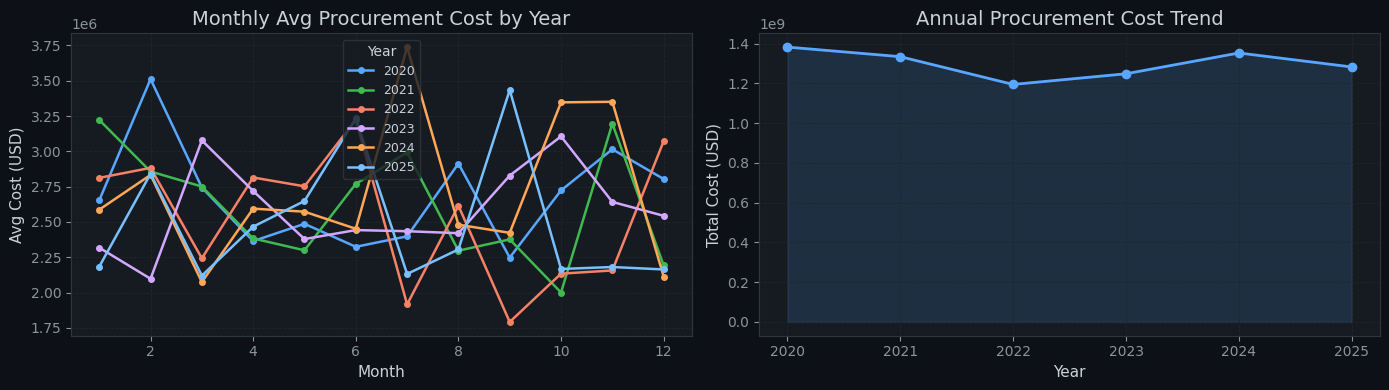

[Figure 6 - Time-Based Feature Trends]


In [34]:
# ── 12.1 Procurement seasonality ────────────
monthly_proc_cost = proc.groupby(['ord_year','ord_month'])['total_cost']\
    .agg(['mean','sum']).reset_index()
monthly_proc_cost.columns = ['year','month',
                              'avg_monthly_proc_cost','total_monthly_proc_cost']

annual_proc = proc.groupby('ord_year')['total_cost'].sum().reset_index()
annual_proc.columns = ['year','annual_proc_cost']
annual_proc['yoy_cost_growth'] = annual_proc['annual_proc_cost'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0D1117')

years = monthly_proc_cost['year'].unique()
for i, yr in enumerate(sorted(years)):
    subset = monthly_proc_cost[monthly_proc_cost['year'] == yr]
    axes[0].plot(subset['month'], subset['avg_monthly_proc_cost'],
                 marker='o', markersize=4, linewidth=1.8,
                 color=DARK_PALETTE[i % len(DARK_PALETTE)], label=str(yr))
axes[0].set_title('Monthly Avg Procurement Cost by Year')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Cost (USD)')
axes[0].legend(title='Year')

axes[1].plot(annual_proc['year'], annual_proc['annual_proc_cost'],
             marker='o', markersize=6, linewidth=2, color='#58A6FF')
axes[1].fill_between(annual_proc['year'], annual_proc['annual_proc_cost'],
                     alpha=0.15, color='#58A6FF')
axes[1].set_title('Annual Procurement Cost Trend')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Cost (USD)')

plt.tight_layout()
plt.show()
print('[Figure 6 - Time-Based Feature Trends]')

In [35]:
# ── 12.2 Sales seasonality features ─────────
monthly_sales = sales.groupby(['year','month'])['net_revenue'].sum().reset_index()
monthly_sales.columns = ['year','month','monthly_revenue']
sales = sales.merge(monthly_sales, on=['year','month'], how='left')

quarterly_profit = sales.groupby(['year','quarter'])['profit_margin_pct'].mean().reset_index()

# Weekend vs weekday average impact on sales and margins
weekend_effect = sales.groupby('is_weekend')[['net_revenue','profit_margin_pct']].mean()
print('Weekend vs Weekday average sales:')
print(weekend_effect)

Weekend vs Weekday average sales:
            net_revenue  profit_margin_pct
is_weekend                                
False       317959.7005            39.8378
True        319192.7401            39.8592


---
## 13. Cross-Domain / Composite Features
These features span multiple tables, capturing end-to-end supply chain dynamics that no single table can express alone.

In [36]:
# ── 13.1 Procurement-to-Sales cost pass-through ──────────────────────────────
# Measures how procurement unit costs feed through into COGS at the sales level
proc_cost_by_prod  = proc.groupby('product_id')['actual_cost_per_unit'].mean().reset_index()
proc_cost_by_prod.columns = ['product_id','avg_proc_unit_cost']

sales_cost_by_prod = sales.groupby('product_id')['unit_cost'].mean().reset_index()
sales_cost_by_prod.columns = ['product_id','avg_sales_unit_cost']

cost_passthrough = proc_cost_by_prod.merge(sales_cost_by_prod, on='product_id', how='inner')
cost_passthrough['cost_passthrough_ratio'] = (
    cost_passthrough['avg_proc_unit_cost'] / (cost_passthrough['avg_sales_unit_cost'] + 1e-9)
)

print('Cost pass-through ratio computed.')
cost_passthrough[['cost_passthrough_ratio']].describe()

Cost pass-through ratio computed.


,cost_passthrough_ratio
count,20.0000
mean,1.7773
std,1.7989
min,0.5731
25%,0.7347
50%,1.0135
75%,1.5291
max,6.9634


In [37]:
# ── 13.2 Demand-Inventory alignment ─────────
# demand_stock_ratio > 1 = undersupplied; < 0.5 = oversupplied
demand_by_prod = sales.groupby('product_id')['quantity_sold'].mean().reset_index()
demand_by_prod.columns = ['product_id','avg_monthly_demand']

stock_by_prod  = inv.groupby('product_id')['stock_level'].mean().reset_index()
stock_by_prod.columns  = ['product_id','avg_stock']

demand_inventory = demand_by_prod.merge(stock_by_prod, on='product_id', how='inner')
demand_inventory['demand_stock_ratio'] = (
    demand_inventory['avg_monthly_demand'] / (demand_inventory['avg_stock'] + 1e-9)
)

demand_inventory['supply_alignment'] = pd.cut(
    demand_inventory['demand_stock_ratio'],
    bins=[0, 0.3, 0.7, 1.3, np.inf],
    labels=['Overstocked','Balanced-Low','Balanced','Undersupplied']
)

print('Demand-inventory alignment features created.')
demand_inventory['supply_alignment'].value_counts()

Demand-inventory alignment features created.


supply_alignment
Overstocked      20
Balanced-Low      0
Balanced          0
Undersupplied     0
Name: count, dtype: int64

In [38]:
# ── 13.3 Total Supply Chain Cost per Product 
# Aggregates procurement + waste + shipping costs against revenue
proc_cost_agg = proc.groupby('product_id')['total_cost'].sum().rename('total_proc_cost')
waste_cost_agg= prod.groupby('product_id')['waste_cost'].sum().rename('total_waste_cost')
ship_cost_agg = ship.groupby('product_id')['shipping_cost'].sum().rename('total_ship_cost')
sales_rev_agg = sales.groupby('product_id')['net_revenue'].sum().rename('total_net_revenue')

sc_cost = pd.concat([proc_cost_agg, waste_cost_agg,
                     ship_cost_agg, sales_rev_agg], axis=1).reset_index().fillna(0)

sc_cost['total_supply_chain_cost'] = (
    sc_cost['total_proc_cost'] +
    sc_cost['total_waste_cost'] +
    sc_cost['total_ship_cost']
)
sc_cost['sc_cost_to_revenue_ratio'] = (
    sc_cost['total_supply_chain_cost'] / (sc_cost['total_net_revenue'] + 1e-9)
)

print('Total supply chain cost features created.')
sc_cost[['total_supply_chain_cost','sc_cost_to_revenue_ratio']].describe()

Total supply chain cost features created.


,total_supply_chain_cost,sc_cost_to_revenue_ratio
count,20.0000,20.0000
mean,499195839.0410,0.2090
std,86727015.9264,0.0355
min,333934459.0356,0.1420
25%,464949728.4869,0.1982
50%,512581261.2148,0.2134
75%,565106703.5686,0.2379
max,602034786.3865,0.2509


---
## 14. Encoding & Final Feature Matrix
Prepare encoded, model-ready DataFrames for each of the three model types: regression, classification, and clustering.

In [39]:
# ── 14.1 Shipment delay classification dataset ────────────────────────────────
le = LabelEncoder()

ship_model = ship[[
    'transit_days','cost_per_kg','cost_per_unit_shipped',
    'carrier_avg_transit','carrier_std_transit','carrier_delay_rate',
    'route_delay_rate','is_international','cust_delay_rate',
    'total_weight_kg','quantity','ship_is_weekend',
    'ship_month','ship_quarter',
    'carrier','channel_type','size',
    'is_delayed'   # TARGET
]].dropna().copy()

for col in ['carrier','channel_type','size']:
    ship_model[col] = le.fit_transform(ship_model[col].astype(str))

print('Shipment delay classification dataset:')
print('  Shape:', ship_model.shape)
print('  Target distribution:', ship_model['is_delayed'].value_counts().to_dict())

Shipment delay classification dataset:
  Shape: (12000, 18)
  Target distribution: {0: 7986, 1: 4014}


In [40]:
# ── 14.2 Procurement cost regression dataset 
proc_model = proc[[
    'order_quantity','lead_time_days','quality_score',
    'supplier_reliability_index','lead_time_cv','cost_efficiency_ratio',
    'unit_cost_premium_pct','monthly_supplier_spend',
    'ord_month','ord_quarter','ord_is_weekend',
    'tier','category',
    'total_cost'   # TARGET
]].dropna().copy()

for col in ['tier','category']:
    proc_model[col] = le.fit_transform(proc_model[col].astype(str))

print('Procurement regression dataset:')
print('  Shape:', proc_model.shape)

Procurement regression dataset:
  Shape: (3000, 14)


In [41]:
# ── 14.3 Profit margin regression dataset 
sales_model = sales[[
    'quantity_sold','discount_pct',
    'gross_margin_pct','revenue_realisation_ratio',
    'customer_profitability_index','cust_avg_discount',
    'monthly_revenue','month','quarter','is_weekend',
    'channel_type','size','category',
    'profit_margin_pct'  # TARGET
]].dropna().copy()

for col in ['channel_type','size','category']:
    sales_model[col] = le.fit_transform(sales_model[col].astype(str))

print('Profit margin regression dataset:')
print('  Shape:', sales_model.shape)

Profit margin regression dataset:
  Shape: (3000, 14)


In [42]:
# ── 14.4 Supplier & customer clustering datasets ──────────────────────────────
supplier_cluster = supplier_profile[[
    'supplier_id','supplier_name','tier',
    'total_orders','total_procurement_spend','avg_lead_time','std_lead_time',
    'avg_quality_score_proc','avg_reliability_index',
    'late_delivery_rate','avg_cost_efficiency','supplier_risk_score'
]].dropna().copy()

customer_cluster = customer_profile[[
    'customer_id','customer_name',
    'total_orders','total_revenue','avg_profit_margin',
    'avg_discount_pct','rfm_score','customer_ltv',
    'cust_delay_rate','product_diversity_index','revenue_cov'
]].dropna().copy()

print('Supplier clustering dataset:', supplier_cluster.shape)
print('Customer clustering dataset:', customer_cluster.shape)

Supplier clustering dataset: (10, 12)
Customer clustering dataset: (5, 11)


---
## 15. Feature Correlation & Selection

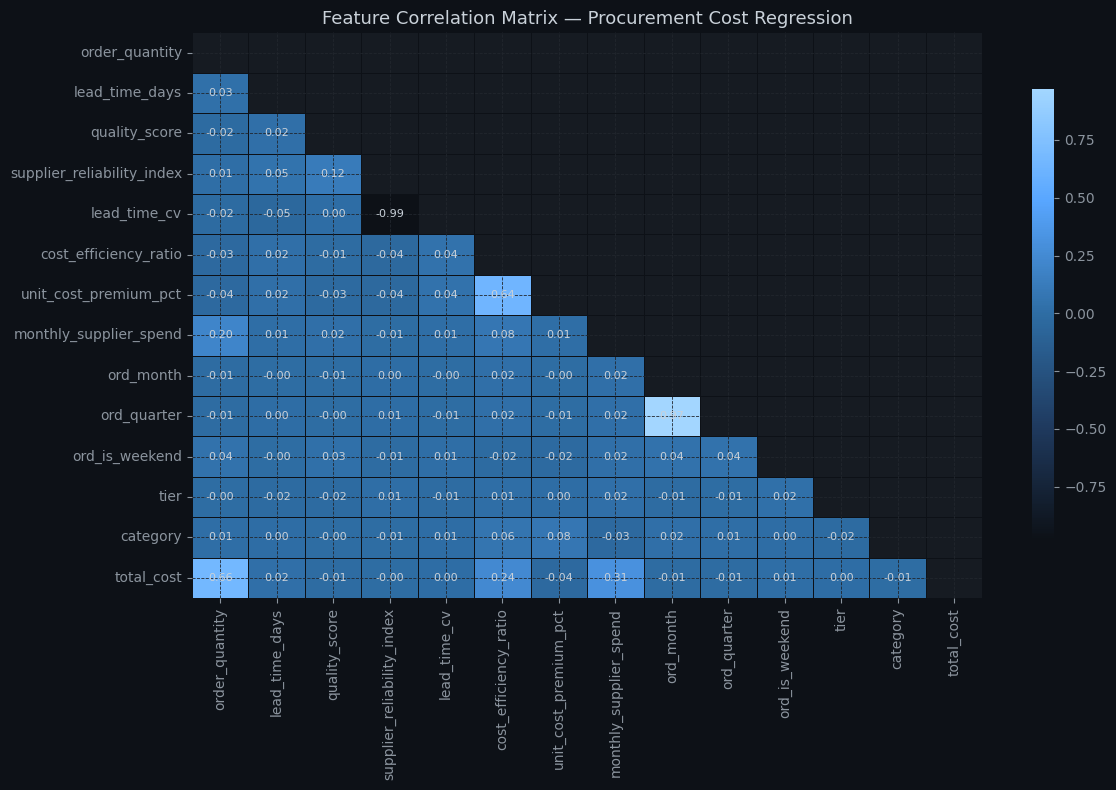

[Figure 7 - Procurement Correlation Heatmap]


In [43]:
# ── 15.1 Correlation heatmap — Procurement regression ────────────────────────
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#0D1117')
corr = proc_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap=CMAP_DARK, center=0,
    ax=ax, linewidths=0.4, linecolor='#0D1117',
    annot_kws={'size': 8, 'color': '#C9D1D9'},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix — Procurement Cost Regression', fontsize=13)
ax.tick_params(colors='#8B949E')
plt.tight_layout()
plt.show()
print('[Figure 7 - Procurement Correlation Heatmap]')

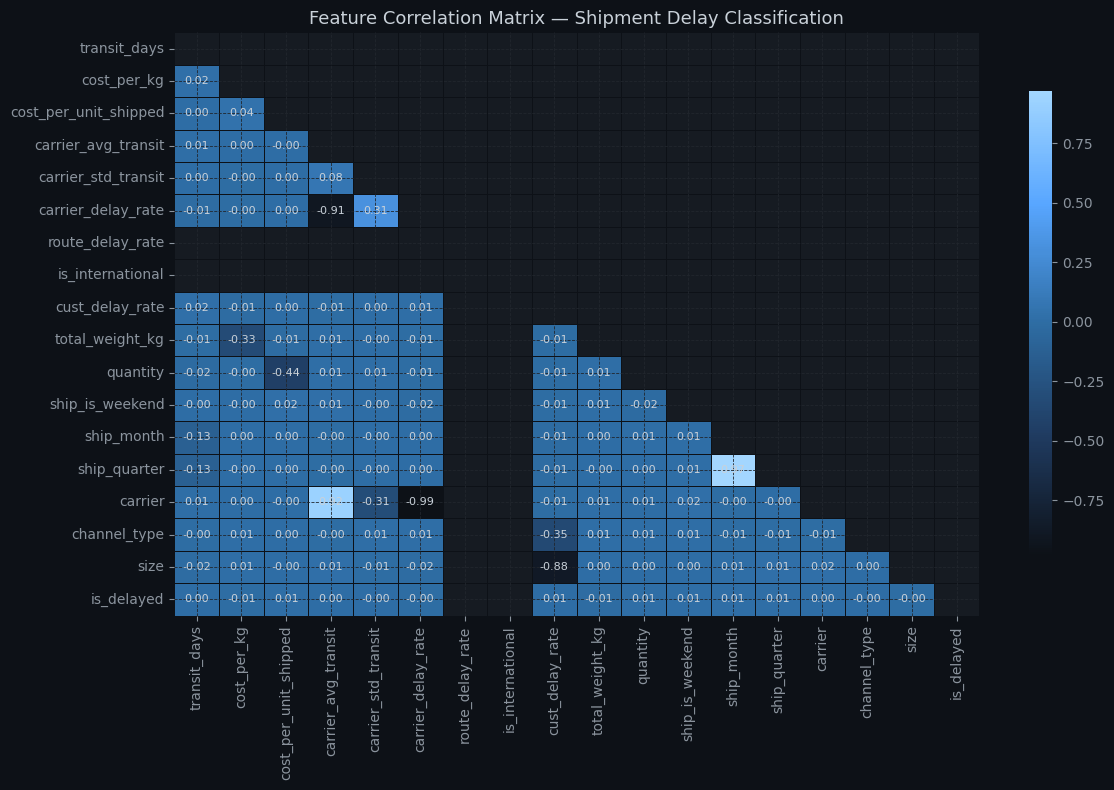

[Figure 8 - Shipment Delay Correlation Heatmap]


In [44]:
# ── 15.2 Correlation heatmap — Shipment delay classification ─────────────────
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#0D1117')
corr2 = ship_model.corr()
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(
    corr2, mask=mask2, annot=True, fmt='.2f',
    cmap=CMAP_DARK, center=0,
    ax=ax, linewidths=0.4, linecolor='#0D1117',
    annot_kws={'size': 8, 'color': '#C9D1D9'},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix — Shipment Delay Classification', fontsize=13)
ax.tick_params(colors='#8B949E')
plt.tight_layout()
plt.show()
print('[Figure 8 - Shipment Delay Correlation Heatmap]')

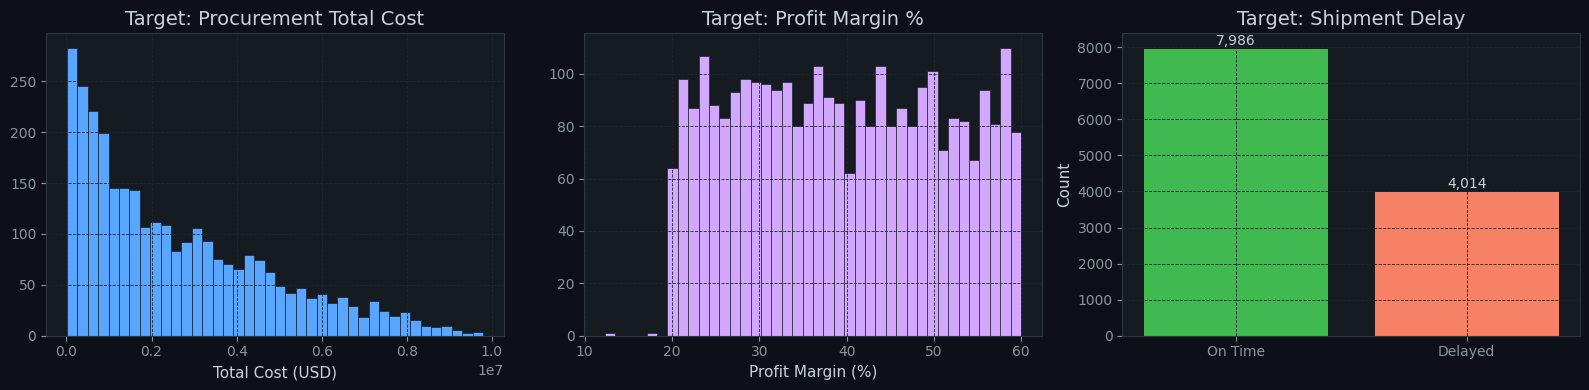

[Figure 9 - Target Variable Distributions]


In [45]:
# ── 15.3 Target variable distributions ──────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='#0D1117')

axes[0].hist(proc_model['total_cost'], bins=40,
             color='#58A6FF', edgecolor='#0D1117', linewidth=0.4)
axes[0].set_title('Target: Procurement Total Cost')
axes[0].set_xlabel('Total Cost (USD)')

axes[1].hist(sales_model['profit_margin_pct'], bins=40,
             color='#D2A8FF', edgecolor='#0D1117', linewidth=0.4)
axes[1].set_title('Target: Profit Margin %')
axes[1].set_xlabel('Profit Margin (%)')

delay_vals = ship_model['is_delayed'].value_counts().sort_index()
bars = axes[2].bar(['On Time','Delayed'], delay_vals.values,
                   color=['#3FB950','#F78166'],
                   edgecolor='#0D1117', linewidth=0.6)
for bar, val in zip(bars, delay_vals.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, color='#C9D1D9')
axes[2].set_title('Target: Shipment Delay')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('[Figure 9 - Target Variable Distributions]')

In [46]:
# ── 15.4 Feature importance ranking via correlation magnitude ─────────────────
corr_proc  = proc_model.corr()['total_cost'].abs()\
                .sort_values(ascending=False).drop('total_cost')
corr_sales = sales_model.corr()['profit_margin_pct'].abs()\
                .sort_values(ascending=False).drop('profit_margin_pct')
corr_ship  = ship_model.corr()['is_delayed'].abs()\
                .sort_values(ascending=False).drop('is_delayed')

print('=== TOP 10 FEATURES — Procurement Cost (|correlation|) ===')
print(corr_proc.head(10).to_string())
print('\n=== TOP 10 FEATURES — Profit Margin (|correlation|) ===')
print(corr_sales.head(10).to_string())
print('\n=== TOP 10 FEATURES — Shipment Delay (|correlation|) ===')
print(corr_ship.head(10).to_string())

=== TOP 10 FEATURES — Procurement Cost (|correlation|) ===
order_quantity           0.6613
monthly_supplier_spend   0.3131
cost_efficiency_ratio    0.2380
unit_cost_premium_pct    0.0351
lead_time_days           0.0154
ord_month                0.0138
ord_is_weekend           0.0126
ord_quarter              0.0126
quality_score            0.0102
category                 0.0071

=== TOP 10 FEATURES — Profit Margin (|correlation|) ===
quarter                        0.0404
month                          0.0396
category                       0.0328
revenue_realisation_ratio      0.0318
channel_type                   0.0261
discount_pct                   0.0223
gross_margin_pct               0.0181
customer_profitability_index   0.0165
monthly_revenue                0.0138
quantity_sold                  0.0134

=== TOP 10 FEATURES — Shipment Delay (|correlation|) ===
total_weight_kg         0.0141
quantity                0.0118
ship_quarter            0.0100
cost_per_unit_shipped   0.0079
co

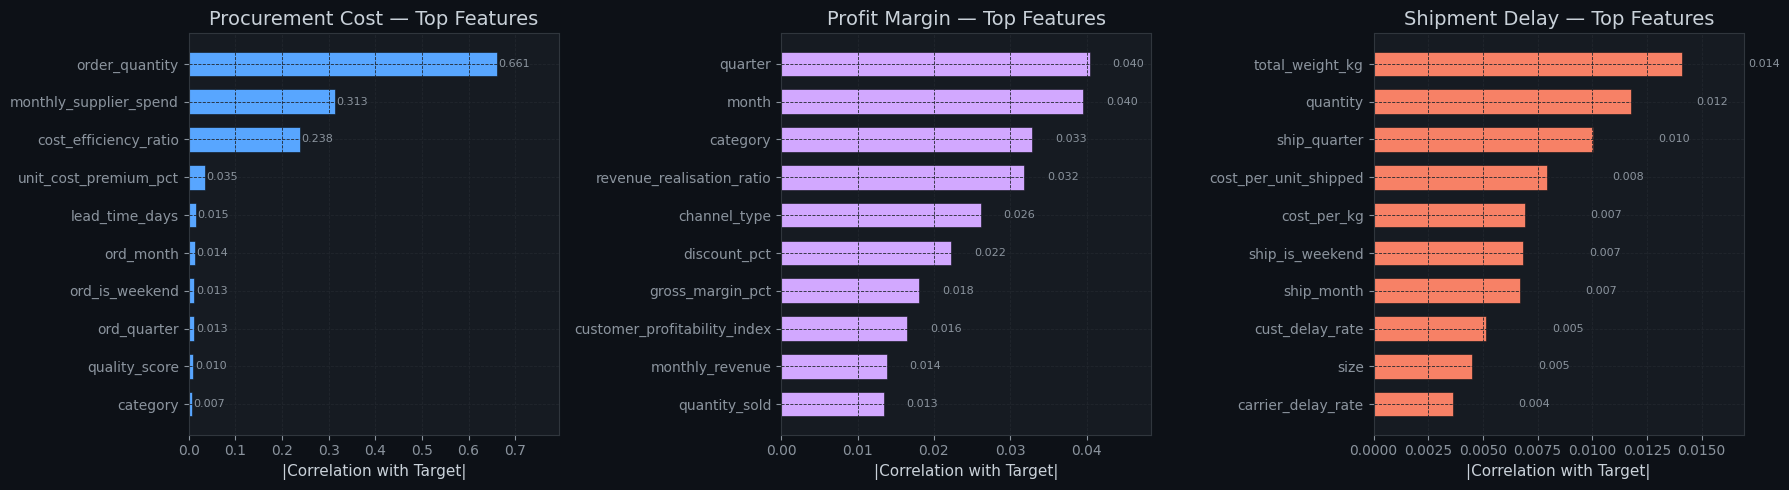

[Figure 10 - Feature Importance (Correlation-Based)]


In [47]:
# ── 15.5 Feature importance bar charts 
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0D1117')

data_list = [
    (corr_proc.head(10).sort_values(),  '#58A6FF', 'Procurement Cost'),
    (corr_sales.head(10).sort_values(), '#D2A8FF', 'Profit Margin'),
    (corr_ship.head(10).sort_values(),  '#F78166', 'Shipment Delay'),
]

for ax, (data, color, title) in zip(axes, data_list):
    bars = ax.barh(data.index, data.values,
                   color=color, edgecolor='#0D1117',
                   linewidth=0.4, height=0.65)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8, color='#8B949E')
    ax.set_title(f'{title} — Top Features')
    ax.set_xlabel('|Correlation with Target|')
    ax.set_xlim(0, data.max() * 1.2)

plt.tight_layout()
plt.show()
print('[Figure 10 - Feature Importance (Correlation-Based)]')

---
## 16. Export Feature Sets
Save all engineered feature datasets for use in Phase 4 — Model Development.

In [48]:
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('features', exist_ok=True)

# ── Model-ready datasets ─────────────────────
proc_model.to_csv('features/procurement_regression_features.csv', index=False)
sales_model.to_csv('features/profit_margin_regression_features.csv', index=False)
ship_model.to_csv('features/shipment_delay_classification_features.csv', index=False)
supplier_cluster.to_csv('features/supplier_clustering_features.csv', index=False)
customer_cluster.to_csv('features/customer_clustering_features.csv', index=False)

# ── Enriched profile tables ──────────────────
supplier_profile.to_csv('features/supplier_profile.csv', index=False)
customer_profile.to_csv('features/customer_profile.csv', index=False)
product_profile.to_csv('features/product_profile.csv', index=False)
facility_profile.to_csv('features/facility_profile.csv', index=False)
sc_cost.to_csv('features/supply_chain_cost_by_product.csv', index=False)

# ── Enriched master fact tables ──────────────
proc.to_csv('features/fact_procurement_engineered.csv', index=False)
prod.to_csv('features/fact_production_engineered.csv', index=False)
sales.to_csv('features/fact_sales_engineered.csv', index=False)
ship.to_csv('features/fact_shipment_engineered.csv', index=False)
inv.to_csv('features/fact_inventory_engineered.csv', index=False)

print('All feature datasets exported to /features/')
print()
print('Files saved:')
for f in sorted(os.listdir('features')):
    path = f'features/{f}'
    size = os.path.getsize(path) / 1024
    print(f'  {f:55s}  {size:>8.1f} KB')

All feature datasets exported to /features/

Files saved:
  customer_clustering_features.csv                              1.0 KB
  customer_profile.csv                                          1.7 KB
  facility_profile.csv                                          1.3 KB
  fact_inventory_engineered.csv                              1925.9 KB
  fact_procurement_engineered.csv                            1531.5 KB
  fact_production_engineered.csv                             3448.8 KB
  fact_sales_engineered.csv                                 86265.4 KB
  fact_shipment_engineered.csv                               6143.0 KB
  procurement_regression_features.csv                         409.5 KB
  product_profile.csv                                           5.0 KB
  profit_margin_regression_features.csv                       446.9 KB
  shipment_delay_classification_features.csv                 1978.7 KB
  supplier_clustering_features.csv                              2.1 KB
  supplier_profile.

In [49]:
# ── Final summary ────────────────────────────
sep = '=' * 68
print(sep)
print('  FEATURE ENGINEERING SUMMARY')
print(sep)

summary = {
    'Procurement Regression Features'   : proc_model.shape,
    'Profit Margin Regression Features' : sales_model.shape,
    'Shipment Delay Classification'     : ship_model.shape,
    'Supplier Clustering Features'      : supplier_cluster.shape,
    'Customer Clustering Features'      : customer_cluster.shape,
}
for name, shape in summary.items():
    print(f'  {name:42s}  {shape[0]:>7,} rows x {shape[1]:>2} features')

print()
print('  KEY ENGINEERED FEATURES BY DOMAIN:')
key_features = [
    ('Inventory',    ['stock_coverage_ratio','reorder_gap',
                      'stockout_risk_flag','inventory_turnover']),
    ('Procurement',  ['supplier_reliability_index','lead_time_cv',
                      'cost_efficiency_ratio','unit_cost_premium_pct']),
    ('Production',   ['production_yield_ratio','high_defect_flag',
                      'waste_cost','defect_trend']),
    ('Sales',        ['gross_margin_pct','revenue_realisation_ratio',
                      'customer_profitability_index','rfm_score']),
    ('Shipment',     ['transit_days','cost_per_kg',
                      'route_delay_rate','is_international']),
    ('Supplier',     ['supplier_risk_score','avg_reliability_index',
                      'late_delivery_rate']),
    ('Cross-Domain', ['sc_cost_to_revenue_ratio','demand_stock_ratio',
                      'cost_passthrough_ratio']),
]
for domain, features in key_features:
    print(f'  [{domain}]  {" | ".join(features)}')
print(sep)

  FEATURE ENGINEERING SUMMARY
  Procurement Regression Features               3,000 rows x 14 features
  Profit Margin Regression Features             3,000 rows x 14 features
  Shipment Delay Classification                12,000 rows x 18 features
  Supplier Clustering Features                     10 rows x 12 features
  Customer Clustering Features                      5 rows x 11 features

  KEY ENGINEERED FEATURES BY DOMAIN:
  [Inventory]  stock_coverage_ratio | reorder_gap | stockout_risk_flag | inventory_turnover
  [Procurement]  supplier_reliability_index | lead_time_cv | cost_efficiency_ratio | unit_cost_premium_pct
  [Production]  production_yield_ratio | high_defect_flag | waste_cost | defect_trend
  [Sales]  gross_margin_pct | revenue_realisation_ratio | customer_profitability_index | rfm_score
  [Shipment]  transit_days | cost_per_kg | route_delay_rate | is_international
  [Supplier]  supplier_risk_score | avg_reliability_index | late_delivery_rate
  [Cross-Domain]  sc_cost